# Optimasi Target Marketing Campaign Deposito Berjangka Menggunakan Machine Learning

**Latar Belakang**

Jenis produk investasi yang digunakan oleh masyarakat semakin beragam. Salah satu produk investasi yang sudah dikenal luas oleh masyarakat adalah deposito berjangka. Mekanisme deposito berjangka adalah nasabah menyimpan sejumlah uang di bank atau lembaga keuangan, dan uang tersebut hanya dapat ditarik setelah jangka waktu tertentu. Sebagai kompensasi, nasabah akan mendapatkan bunga tetap sesuai dengan nominal uang yang disetorkan.

Namun demikian, sebagai entitas bisnis yang menawarkan produk keuangan dan memiliki nasabah masing-masing, bank tetap harus bersaing agar tidak kehilangan nasabah. Salah satu cara untuk memperoleh nasabah baru adalah dengan melakukan marketing campaign.


**Problem Statement**

Tantangan utama yang dihadapi oleh bank adalah bagaimana memprediksi perilaku nasabah, terutama apakah mereka akan melakukan deposito atau tidak dalam campaign yang akan ditawarkan kedepannya, karena kesalahan dalam memprediksi perilaku nasabah dapat mengakibatkan kerugian finansial dan kehilangan peluang bisnis yang berharga.

Untuk mengatasi tantangan ini, penggunaan teknologi machine learning akan menjadi sangat tepat, dimana akan dilakukan marketing campaign berdasarkan data historis campaign yang sudah berjalan sebelumnya.

**Tujuan**

Berdasarkan permasalahan tersebut, perusahaan ingin memiliki kemampuan untuk mengembangkan model machine learning yang dapat membantu bank dalam memprediksi kemungkinan seorang nasabah akan melakukan deposito berjangka atau tidak, sehingga dapat memfokuskan pada calon nasabah yang bersedia melakukan deposito berjangka tersebut.

Dan juga, perusahaan ingin mengetahui faktor atau variabel apa yang membuat seorang nasabah mau melakukan deposito atau tidak, sehingga dapat membuat rencana yang lebih baik dalam mendekati calon nasabah potensial.

1. Dapat membantu bank dalam memprediksi kemungkinan seorang nasabah akan melakukan deposito berjangka atau tidak, sehingga dapat memfokuskan pada calon nasabah yang bersedia melakukan deposito berjangka tersebut.
2. Perusahaan ingin mengetahui faktor atau variabel apa yang membuat seorang nasabah mau melakukan deposito atau tidak, sehingga dapat membuat rencana yang lebih baik dalam mendekati calon nasabah potensial.

**Matrics Evaluation**

Type 1 error : False Positive
* Nasabah tidak ingin melakukan deposit tetapi campaign tetap dikirimkan
* Konsekuensi: Sia-sianya waktu dan resource yang digunakan untuk menawarkan campaign ini.

Type 2 error : False Negative
* Nasabah ingin melakukan deposit tetapi tidak ditargetkan dalam campaign
* Konsekuensi: Kehilangan calon potensial nasabah yang akan melakukan deposit.


Berdasarkan konsukensi diatas maka **fokus utama dari project ini adalah untuk mereduksi False Negative**, yaitu di mana kasus model memprediksi bahwa seorang nasabah tidak akan melakukan deposito padahal seharusnya ia melakukannya, kerugian bagi bank dalam hal ini ialah kehilangan potensi pendapatan dari deposito berjangka.

Matrics utama:
1. Recall (Sensitivity) kelas 1
   *  Mengukur seberapa banyak nasabah yang benar-benar mau deposito berhasil ditangkap model
2. F2-Score
   *  Lebih menekankan Recall dibanding Precision cocok untuk kasus lost opportunity
3. Confusion Matrix
   *  Untuk interpretasi bisnis


**Analytical Framing**

| Aspek | Penjelasan |
| --- | --- |
| Jenis ML | Supervised Learning |
| Target | 0 = Tidak Deposit, 1 = Deposit |
| Risiko Terbesar | Type 2 Error - False Negative |
| Fokus Metric | Recall (Class 1) |

### Attribute Information

| Attribute | Data Type, Length | Description |
| --- | --- | --- |
| age | int64 | Usia nasabah |
| job | object | Pekerjaan nasabah |
| balance | int64 | Saldo rekening nasabah (USD) |
| housing | object | Kepemilikan kredit rumah |
| loan | object | Kepemilikan pinjaman dana |
| contact | object | Tipe media komunikasi yang digunakan menghubungi nasabah |
| month | object | Bulan terakhir kontak dalam satu tahun |
| campaign | int64 | jumlah kontak yang dilakukan selama kampanye ini untuk nasabah tersebut |
| pdays | int64 | Jumlah hari sejak terakhir kali nasabah dihubungi pada kampanye sebelumnya  |
| poutcome | object | Hasil dari kampanye pemasaran sebelumnya |
| deposit | object | Apakah nasabah sudah melakukan deposit atau belum |

In [7]:
# Library
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import category_encoders as ce
from category_encoders import BinaryEncoder

# Uji statistik
from scipy.stats import chi2_contingency, mannwhitneyu

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, recall_score, precision_score, fbeta_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.base import clone
from scipy.stats import randint, uniform, loguniform


# Imbalance Dataset (Keeping the original Pipeline import as sklearn.pipeline is used)

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [8]:
df = pd.read_csv('data_bank_marketing_campaign.csv')
display(df.head(),df.tail())

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
7808,62,housemaid,2,no,no,cellular,nov,1,-1,unknown,yes
7809,48,housemaid,5473,no,no,cellular,feb,2,184,success,yes
7810,36,unknown,179,no,no,cellular,aug,8,-1,unknown,no
7811,31,admin.,54,yes,no,cellular,nov,1,-1,unknown,no
7812,60,retired,1588,no,no,cellular,oct,1,-1,unknown,yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


In [10]:
pd.set_option('display.max_colwidth', None)
# data unique di tiap kolom
list_item = []
for col in df.columns :
    list_item.append( [col, df[col].nunique(), df[col].unique()])

tabel_desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'], data=list_item)
tabel_desc

,Column Name,Number of Unique,Unique Sample
0,age,75,"[55, 39, 51, 38, 36, 41, 37, 35, 57, 23, 33, 31, 53, 30, 46, 48, 25, 29, 28, 52, 49, 44, 42, 27, 47, 64, 26, 34, 56, 32, 58, 45, 54, 50, 79, 65, 40, 24, 60, 43, 61, 59, 62, 68, 82, 71, 73, 76, 69, 20, 72, 22, 67, 19, 70, 75, 63, 93, 77, 80, 66, 21, 87, 81, 92, 88, 84, 83, 78, 74, 18, 85, 95, 86, 90]"
1,job,12,"[admin., self-employed, services, housemaid, technician, management, student, blue-collar, entrepreneur, retired, unemployed, unknown]"
2,balance,3153,"[1662, -3058, 3025, -87, 205, -76, 4803, 911, 805, 0, 1234, 1107, 1170, 341, 4808, 88, 169, 863, 242, 2597, 4929, 277, 1438, 15, 3733, 204, 1684, 1025, 55, 19, 348, 785, 742, 511, 6651, 1612, 555, 54, 1185, 110, 950, 412, 228, 367, 3993, 2599, 3528, 32, 551, 3161, 533, 8725, 349, 514, 2688, -194, 154, 874, 2, 5953, 1269, -327, 235, 7, 2661, 1948, 20, 502, 193, 13658, 1716, 172, 1667, 157, 8, 951, 427, 241, 469, 2060, 7177, 655, -114, 588, -971, 4570, 250, 131, 93, 22, 15341, 356, 190, -124, 2228, -60, 376, 1567, 855, 4151, ...]"
3,housing,2,"[no, yes]"
4,loan,2,"[no, yes]"
5,contact,3,"[cellular, telephone, unknown]"
6,month,12,"[jun, apr, may, nov, jan, sep, feb, mar, aug, jul, oct, dec]"
7,campaign,32,"[2, 3, 1, 4, 5, 6, 7, 30, 8, 9, 11, 14, 10, 28, 63, 12, 24, 17, 15, 18, 19, 13, 21, 23, 22, 33, 16, 25, 26, 20, 29, 43]"
8,pdays,422,"[-1, 352, 21, 91, 186, 263, 96, 355, 294, 412, 89, 114, 276, 93, 175, 57, 323, 156, 86, 95, 271, 182, 289, 334, 269, 309, 144, 183, 417, 138, 254, 337, 171, 389, 87, 170, 165, 372, 247, 98, 196, 469, 272, 104, 63, 587, 336, 145, 130, 28, 202, 324, 147, 94, 328, 420, 179, 90, 81, 160, 298, 356, 357, 267, 430, 52, 181, 365, 237, 330, 103, 374, 75, 133, 321, 204, 782, 266, 197, 270, 318, 349, 187, 359, 490, 192, 227, 100, 168, 177, 251, 301, 350, 92, 184, 345, 290, 199, 333, 169, ...]"
9,poutcome,4,"[unknown, other, failure, success]"


Secara umum, kita bisa melihat bahwa:

* Dataset dari data_bank_marketing_campaign  memiliki 11 kolom dengan 7813 baris
* Nama-nama kolom pada dataset tersebut sudah konsisten dalam penamaannya, yaitu menggunakan lower case.
* Kolom `age`: Terdapat 75 nilai usia unik, menunjukkan variasi usia nasabah yang cukup beragam dalam dataset.
* Kolom `job`: Terdapat 12 jenis pekerjaan unik, termasuk 'unknown' yang nantinya mungkin perlu penanganan khusus (seperti pengelompokan).
* Kolom `balance`: Memiliki 3153 nilai unik, yang menunjukkan rentang saldo rekening nasabah, termasuk adanya **nilai negatif** yang menandakan nasabah dengan saldo terutang atau overdraft.
* Kolom `housing` dan `loan`: Kedua kolom ini adalah biner ('yes' atau 'no'), menunjukkan status kepemilikan kredit rumah dan pinjaman pribadi nasabah yang nanti bisa dianalisis secara lebih lanjut.
* Kolom `contact`: Terdapat 3 jenis media komunikasi ('cellular', 'telephone', 'unknown'). Kategori 'unknown' memerlukan analisis karena mengindikasikan informasi yang hilang mengenai cara kontak.
* Kolom `month`: Terdapat 12 bulan, yang berarti data mencakup kontak kampanye sepanjang satu tahun penuh.
* Kolom `campaign`: Terdapat 32 nilai unik untuk jumlah kontak yang dilakukan selama kampanye ini, menunjukkan variasi dalam intensitas kampanye terhadap nasabah.
* Kolom `pdays`: Memiliki 328 nilai unik, dengan adanya **nilai -1** yang secara spesifik mengindikasikan bahwa nasabah tersebut belum pernah dihubungi pada kampanye sebelumnya menjadikan informasi yang penting untuk feature engineering.
* Kolom `poutcome`: Terdapat 4 hasil kampanye ('unknown', 'other', 'failure', 'success'). Kategori 'unknown' dan 'other' perlu digabungkan sebagai satu kategori.
* Kolom `deposit`: Kolom target yang nilai biner ('yes' atau 'no'), menunjukkan apakah nasabah melakukan deposit berjangka atau tidak.

In [11]:
display(df.describe(), df.describe(include='object'))

,age,balance,campaign,pdays
count,7813.000000,7813.000000,7813.000000,7813.000000
mean,41.257264,1512.448611,2.519775,51.408550
std,11.919710,3089.291831,2.727001,108.072739
min,18.000000,-6847.000000,1.000000,-1.000000
25%,32.000000,127.000000,1.000000,-1.000000
50%,39.000000,549.000000,2.000000,-1.000000
75%,49.000000,1684.000000,3.000000,40.000000
max,95.000000,66653.000000,63.000000,854.000000


,job,housing,loan,contact,month,poutcome,deposit
count,7813,7813,7813,7813,7813,7813,7813
unique,12,2,2,3,12,4,2
top,management,no,no,cellular,may,unknown,no
freq,1792,4140,6789,5628,1976,5819,4081


## Data Cleaning & Data Formatting

In [12]:
df_cleaning = df.copy()

### Data Duplicate

In [13]:
# Cek kolom dan baris duplikat
df_cleaning.columns[df.columns.duplicated()]

Index([], dtype='object')

In [14]:
display(df_cleaning.duplicated().sum())
display(df_cleaning[df_cleaning.duplicated()])

np.int64(8)

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
2944,40,blue-collar,0,yes,no,unknown,may,2,-1,unknown,no
4368,60,management,0,no,no,cellular,aug,3,-1,unknown,yes
4874,41,management,0,no,no,cellular,aug,2,-1,unknown,no
5326,44,blue-collar,0,yes,no,cellular,jul,1,-1,unknown,no
5609,39,technician,0,yes,no,unknown,may,1,-1,unknown,no
5681,38,technician,0,no,no,cellular,aug,2,-1,unknown,no
5905,34,management,0,no,no,cellular,aug,2,-1,unknown,no
7077,30,blue-collar,239,yes,no,unknown,may,1,-1,unknown,yes


Terdapat 8 baris duplicate dari data tersebut, sehingga kita akan drop baris duplicate tersebut

In [15]:
df_cleaning.drop_duplicates(inplace=True)
df_cleaning.duplicated().sum()

np.int64(0)

Setelah dilakukan tindakan, sudah tidak ada lagi duplicated pada baris

### Feature Engineering

In [16]:
# Identifikasi kolom pdays yang angka di bawah 0
display (df.loc[df['pdays'] < 0, 'pdays'].unique())
display((df['pdays'] < 0).sum())

array([-1])

np.int64(5817)

Pada kolom `pdays` memiliki nilai -1 yang mengindikasikan bahwa nasabah belum pernah dihubungi sebelumnya dalam kampanye. Nilai ini bukan merupakan jumlah hari yang sebenarnya, sehingga akan lebih baik jika ditangani secara terpisah.

In [17]:
# Membuat fitur baru untuk memisahkan yang sudah pernah dihubungi dan belum sama sekali
df_cleaning['pdays_contacted'] = df_cleaning['pdays'].apply(lambda x: 0 if x == -1 else 1)

# Menampilkan count dan persentase
jumlah_contacted = df_cleaning['pdays_contacted'].value_counts()
proporsi_contacted = df_cleaning['pdays_contacted'].value_counts(normalize=True) * 100

pd.DataFrame({'Count': jumlah_contacted,'Percentage': proporsi_contacted})

,Count,Percentage
pdays_contacted,,
0,5809,74.42665
1,1996,25.57335


Kolom `pdays_contacted` adalah hasil *feature engineering* dari kolom `pdays` yang original. Pada data mentah, nilai `-1` di kolom `pdays` menunjukkan bahwa nasabah tersebut belum pernah dihubungi sebelumnya dalam kampanye pemasaran. Untuk memisahkan informasi ini dengan lebih jelas, kolom `pdays_contacted` dibuat dengan definisi:
*   **`0`**: Nasabah belum pernah dihubungi sebelumnya (nilai `pdays` sama dengan -1).
*   **`1`**: Nasabah sudah pernah dihubungi sebelumnya (nilai `pdays` lebih besar dari -1).

Dari total 7805 nasabah setelah duplikasi dihapus, terdapat 5809 nasabah atau sekitar 74,43% yang belum pernah dihubungi sebelumnya (ditandai dengan `0` di `pdays_contacted`) dan 1996 nasabah atau sekitar 25,53% yang sudah pernah dihubungi (`1` di `pdays_contacted`). Ini menunjukkan bahwa mayoritas nasabah dalam dataset ini belum memiliki riwayat pernah dihubungi dari kampanye sebelumnya.

In [18]:
# Ubah nilai -1 di 'pdays' menjadi NaN
df_cleaning['pdays'] = df_cleaning['pdays'].replace(-1, np.nan)

In [19]:
df_cleaning['pdays_bin'] = pd.cut(
    df_cleaning['pdays'],
    bins=[0, 7, 30, 90, 180, 365, df_cleaning['pdays'].max()],
    labels=['≤7', '8–30', '31–90', '91–180', '181–365', '>365']
)

df_cleaning['pdays_bin'] = df_cleaning['pdays_bin'].cat.add_categories('never_contacted')
df_cleaning['pdays_bin'] = df_cleaning['pdays_bin'].fillna('never_contacted')

df_cleaning['pdays_bin'].value_counts()

pdays_bin
never_contacted    5809
181–365             926
91–180              673
31–90               191
>365                173
8–30                 22
≤7                   11
Name: count, dtype: int64

Nilai `pdays` = -1 tidak diperlakukan sebagai missing value murni, melainkan **sebagai indikator bahwa nasabah belum pernah dihubungi pada campaign sebelumnya**. Sehingga dilakukan feature engineering dengan memisahkan informasi tersebut ke dalam feature pdays_contacted dan pdays_bin sebagai bahan untuk melakukan tahap EDA.

Sementara itu nilai NaN pada `pdays` ini akan diatasi secara otomatis di dalam pipeline, agar model nantinya bisa bersifat Robust saat bertemu data baru di kemudian hari yang juga memiliki nilai **-1**.


**Catatan:**

*   Jika -1 dibiarkan atau diimputasi secara manual akan merusak logika model dan akan mendistorsi statistik deskriptif pada tahap EDA.


---

Yang telah dilakukan pada kolom `pdays` sebagai berikut:
1.  Mengubah nilai **-1** di kolom `pdays` menjadi **np.nan** agar dapat diperlakukan sebagai dan akan di atasi pada tahap pre-processing  dengan menggunakan **pipeline**.
2.  Membuat fitur biner baru `pdays_contacted` yang bernilai 1 jika nasabah pernah dihubungi sebelumnya dan 0 jika belum pernah dihubungi.
3.  Membuat fitur `pdays_bin` baru ` dengan mengelompokan beberapa kategori menjadi '≤7', '8–30', '31–90', '91–180', '181–365', '>365', never contacted.

In [20]:
# Me-replace nilai 'other' menjadi 'failure' pada kolom 'poutcome'
poutcome_before = df_cleaning['poutcome'].value_counts()
display(poutcome_before)

df_cleaning['poutcome'] = df_cleaning['poutcome'].replace({'other': 'failure'})
poutcome_after = df_cleaning['poutcome'].value_counts()
display(poutcome_after)

poutcome
unknown    5811
failure     848
success     761
other       385
Name: count, dtype: int64

poutcome
unknown    5811
failure    1233
success     761
Name: count, dtype: int64

Diasumsikan pada kolom `poutcome`:
1. Kategori `success` merupakan hasil dari kampanye sebelumnya yang sukses melakukan program deposit sebelumnya dengan total 761 nasabah.
2. Kategori `failure` merupakan hasil dari kampanye sebelumnya yang tidak melakukan program deposit sebelumnya dengan total 848 nasabah.
3. Kategori `unknown` merupakan hasil dari nasabah yang belum pernah dihubungi pada kampanye deposit sebelumnya.
4. Kategori `other`	merupakan hasil dari nasabah yang pernah dihubungi sebelumnya, tapi hasilnya ambigu.

Sehingga diambil keputusan untuk kategori `other` digabung ke dalam kategori `failure` karena keduanya sama-sama pernah dihubungi, tidak menghasilkan success, dan perlakuan campaign hampir sama

In [21]:
# Mengganti nilai 'unknown' menjadi 'other'
df_cleaning['contact'] = df_cleaning['contact'].replace({'unknown': 'other'})
df_cleaning['contact'].value_counts()

contact
cellular     5623
other        1636
telephone     546
Name: count, dtype: int64

Pada fitur `contact` kategori unknown dirubah menjadi other agar secara makna bisnis tidak ambigu

In [22]:
# Mengganti nilai 'unknown' menjadi 'other'
df_cleaning['job'] = df_cleaning['job'].replace({'unknown': 'other', 'admin.':'admin'})
df_cleaning['job'].value_counts()

job
management       1789
blue-collar      1343
technician       1289
admin             936
services          658
retired           540
self-employed     280
unemployed        249
student           247
entrepreneur      236
housemaid         184
other              54
Name: count, dtype: int64

Pada fitur `contact` kategori unknown dirubah menjadi other agar secara makna bisnis tidak ambigu

In [23]:
# Membuat feature age_group untuk mengelompokan umur
bins = [18, 25, 40, 60, 75, df_cleaning['age'].max()]
labels = ['Young Adults', 'Early Adulthood', 'Middle-Aged Adults', 'Older Adults', 'Seniors']

df_cleaning['age_group'] = pd.cut(df_cleaning['age'], bins=bins, labels=labels, right=True, include_lowest=True)

df_cleaning['age_group'].value_counts().sort_index()

age_group
Young Adults           307
Early Adulthood       4038
Middle-Aged Adults    3020
Older Adults           334
Seniors                106
Name: count, dtype: int64

Diputuskan membuat fitur baru dengan nama `age_group` agar mempermudah identifikasi kelompok umur pada tahap EDA nanti.
* Young Adults (18-25 tahun): 307 nasabah
* Early Adulthood (26-40 tahun): 4038 nasabah
* Middle-Aged Adults (41-60 tahun): 3020 nasabah
* Older Adults (61-75 tahun): 334 nasabah
* Seniors (76-95 tahun): 106 nasabah

### Missing Value

In [24]:
# Identifikasi missing value
missing_data = pd.DataFrame({'Missing Count': df_cleaning.isna().sum(),'Missing Percentage': df_cleaning.isna().sum() / df.shape[0] * 100})
display(missing_data[missing_data['Missing Count'] > 0])

,Missing Count,Missing Percentage
pdays,5809,74.350442


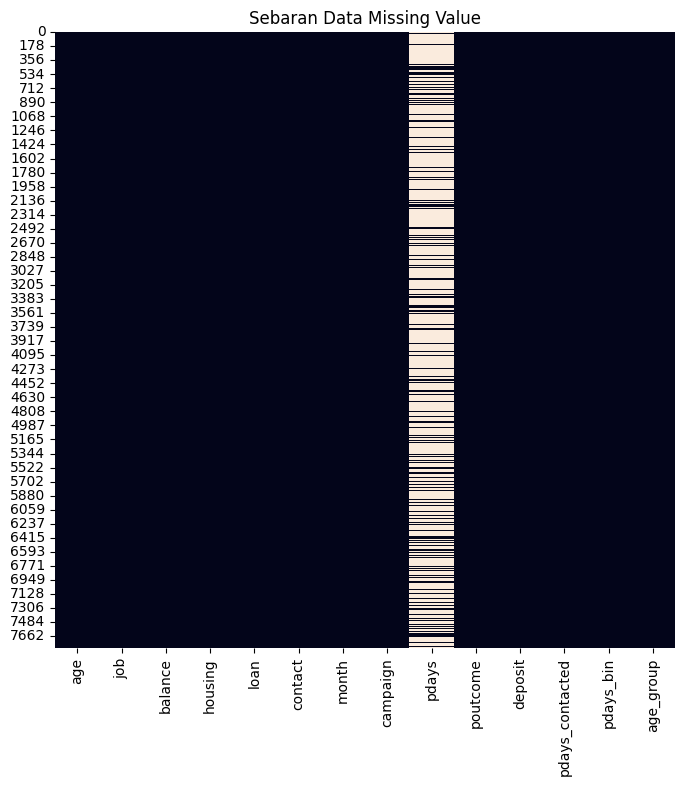

In [25]:
# Sebaran missing value di dalam data
plt.figure(figsize=(8,8))
sns.heatmap (df_cleaning.isna(), cbar=False)
plt.title('Sebaran Data Missing Value')
plt.show()

Selain dari kolom `pdays` tidak adalagi yang mengalami missing value. Kolom pdyas ini akan diatasi melalui tahap pre-processing pipeline

In [26]:
df_cleaning.columns

Index(['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month',
       'campaign', 'pdays', 'poutcome', 'deposit', 'pdays_contacted',
       'pdays_bin', 'age_group'],
      dtype='object')

In [27]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7805 entries, 0 to 7812
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              7805 non-null   int64   
 1   job              7805 non-null   object  
 2   balance          7805 non-null   int64   
 3   housing          7805 non-null   object  
 4   loan             7805 non-null   object  
 5   contact          7805 non-null   object  
 6   month            7805 non-null   object  
 7   campaign         7805 non-null   int64   
 8   pdays            1996 non-null   float64 
 9   poutcome         7805 non-null   object  
 10  deposit          7805 non-null   object  
 11  pdays_contacted  7805 non-null   int64   
 12  pdays_bin        7805 non-null   category
 13  age_group        7805 non-null   category
dtypes: category(2), float64(1), int64(4), object(7)
memory usage: 808.5+ KB


Berdasarkan output dari df_cleaning.info(), terdapat beberapa informasi penting mengenai struktur dan kondisi data setelah tahap data cleaning dan feature engineering:

1. **Jumlah Baris dan Kolom**: Pada data `df_cleaning` sekarang memiliki **7805 baris** dan **14 kolom**. Hal ini menunjukkan bahwa duplikat data telah berhasil dihapus (dari 7813 menjadi 7805 baris) dan beberapa fitur baru telah ditambahkan seperti pdays_contacted, pdays_bin, age_group untuk kebutuhan tahap EDA.

2. **Informasi Missing Value**:
   * Kolom `pdays` memiliki **1996 nilai non-null** dari total 7805 baris. Ini berarti terdapat **5809 nilai yang null**. Hal ini sejalan dengan langkah sebelumnya yang mana nilai -1 diubah menjadi **np.nan** untuk penanganan lebih lanjut di dalam **pipeline**.
   * Semua kolom lainnya (age, job, balance, housing, loan, contact, month, campaign, poutcome, deposit, pdays_contacted, pdays_bin, age_group) sudah bersih dari missing value.

3. **Tipe Data Kolom (Dtypes)**:
   * Ada 5 kolom numerik integer (int64): age, balance, campaign, pdays_contacted.
   * Ada 1 kolom numerik float (float64): pdays
   * Ada 7 kolom kategorikal bertipe objek (object): job, housing, loan, contact, month, poutcome, dan deposit.
   * Ada 2 kolom kategorikal yang baru dibuat (category): pdays_bin dan age_group.

Secara keseluruhan, output ini mengkonfirmasi bahwa proses pembersihan data dan feature engineering telah mengubah struktur data serta mengidentifikasi kolom pdays sebagai satu-satunya yang masih memiliki missing value (yang memang disengaja untuk diatasi di tahap preprocessing pipeline).


## Data Outlier

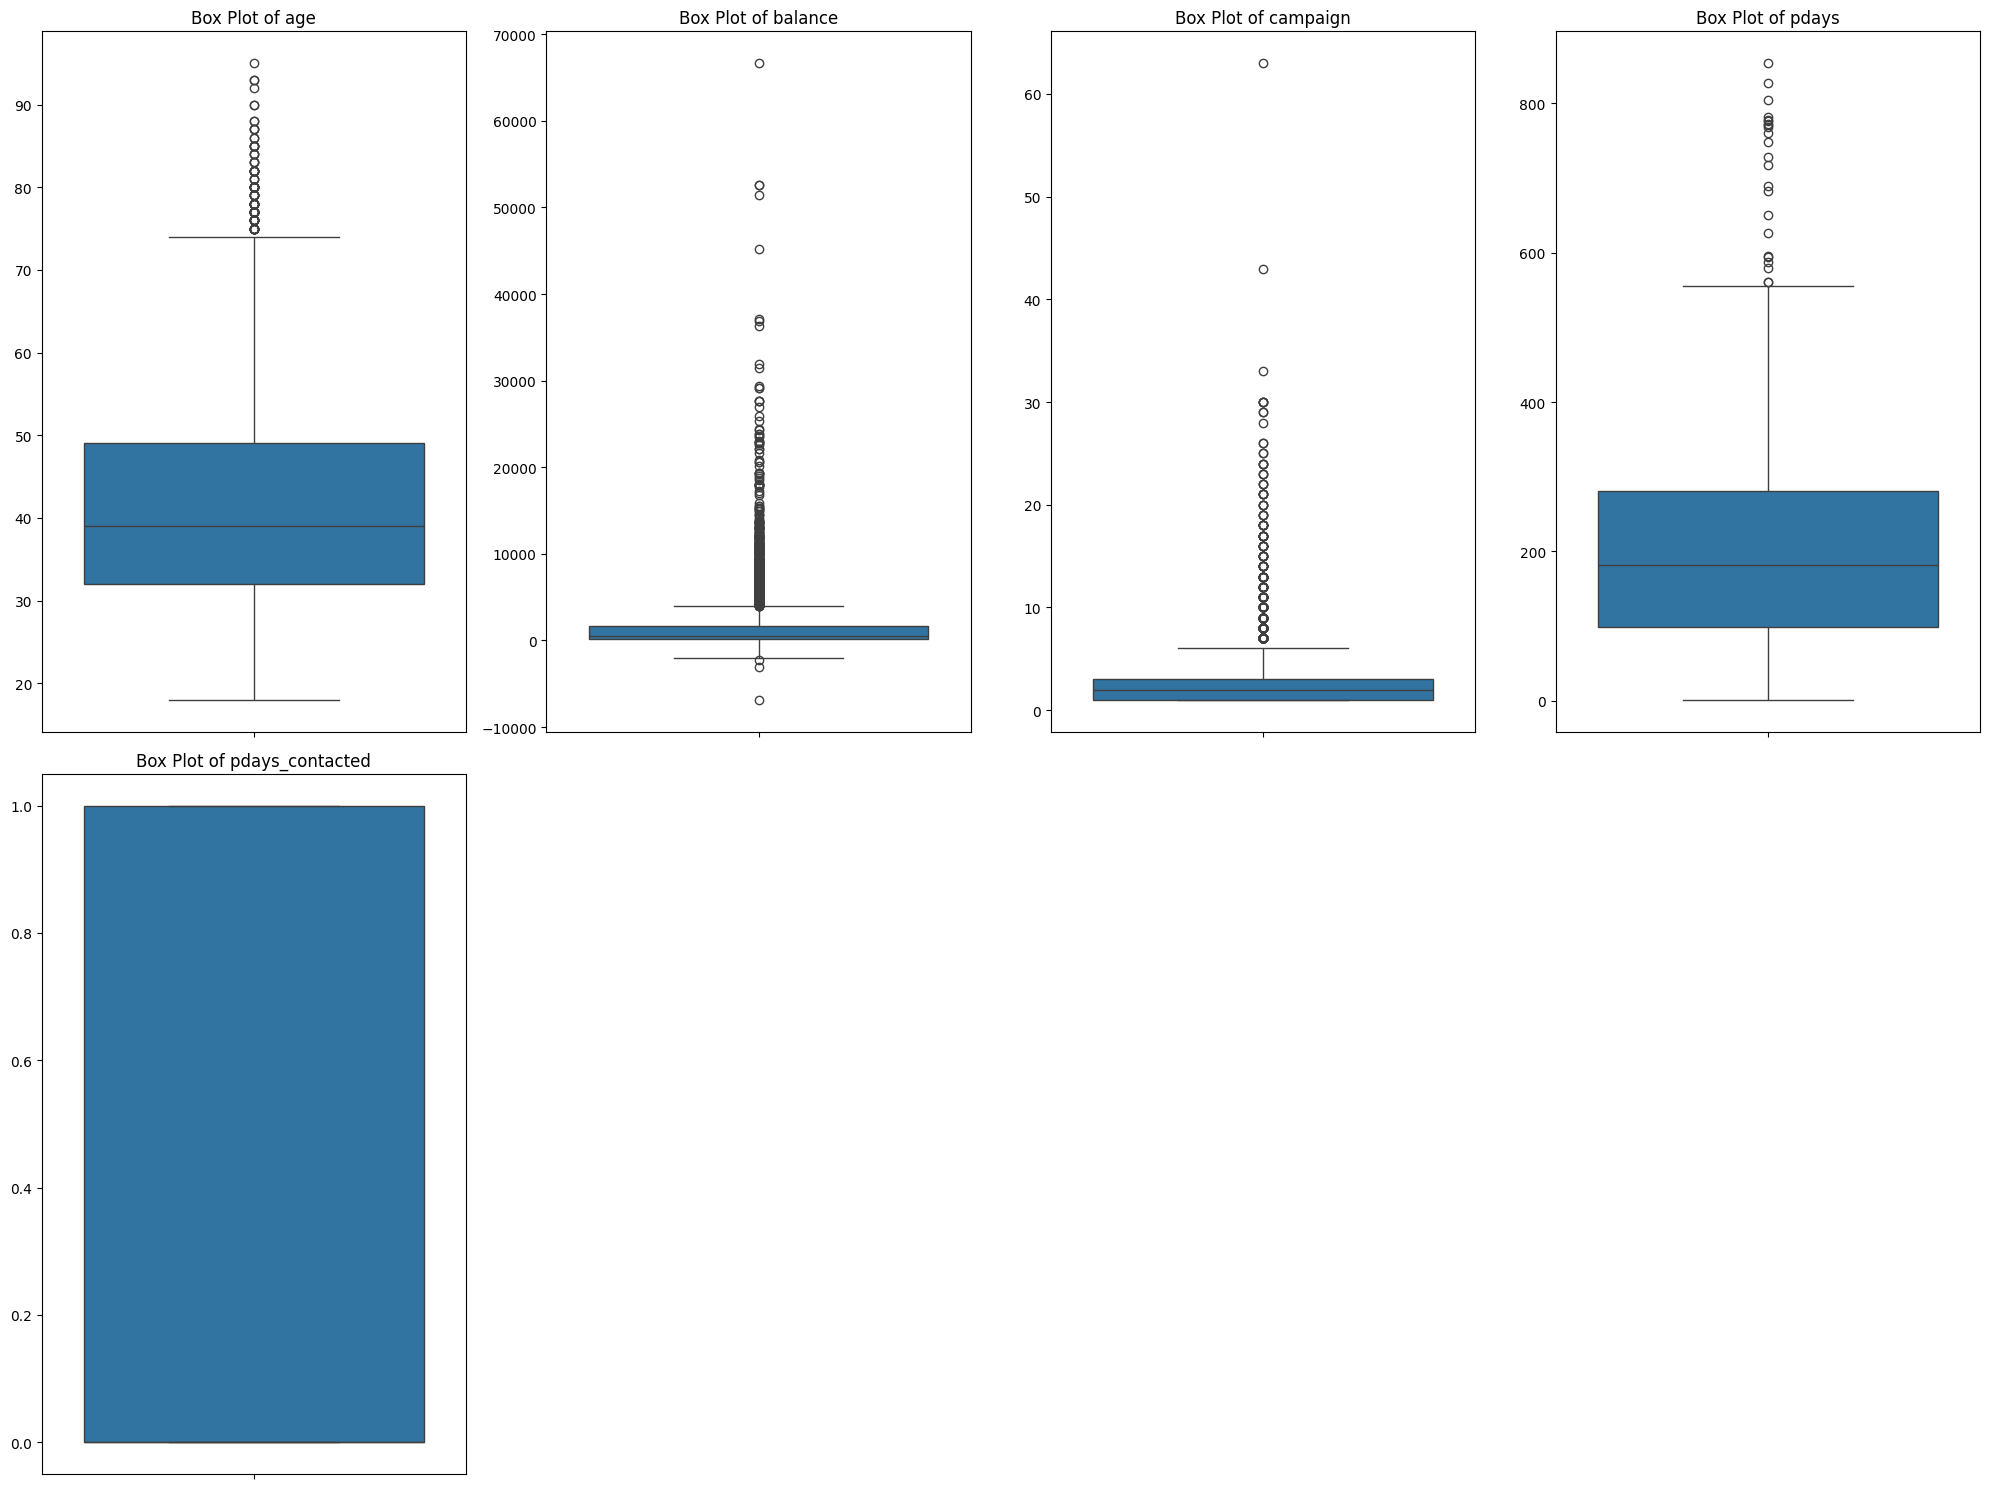

In [28]:
# Pengecekan data outlier dengan boxplot
numerical_cols = df_cleaning.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(round(len(numerical_cols)/4) +1, 4, i + 1)
    sns.boxplot(y=df_cleaning[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Balance yang minus tidak perlu di-0-kan. Saldo negatif itu sendiri adalah informasi yang berharga. Mengubahnya menjadi 0 akan menghilangkan informasi penting tentang kondisi finansial nasabah (misalnya, nasabah yang sedang overdraft atau berhutang).

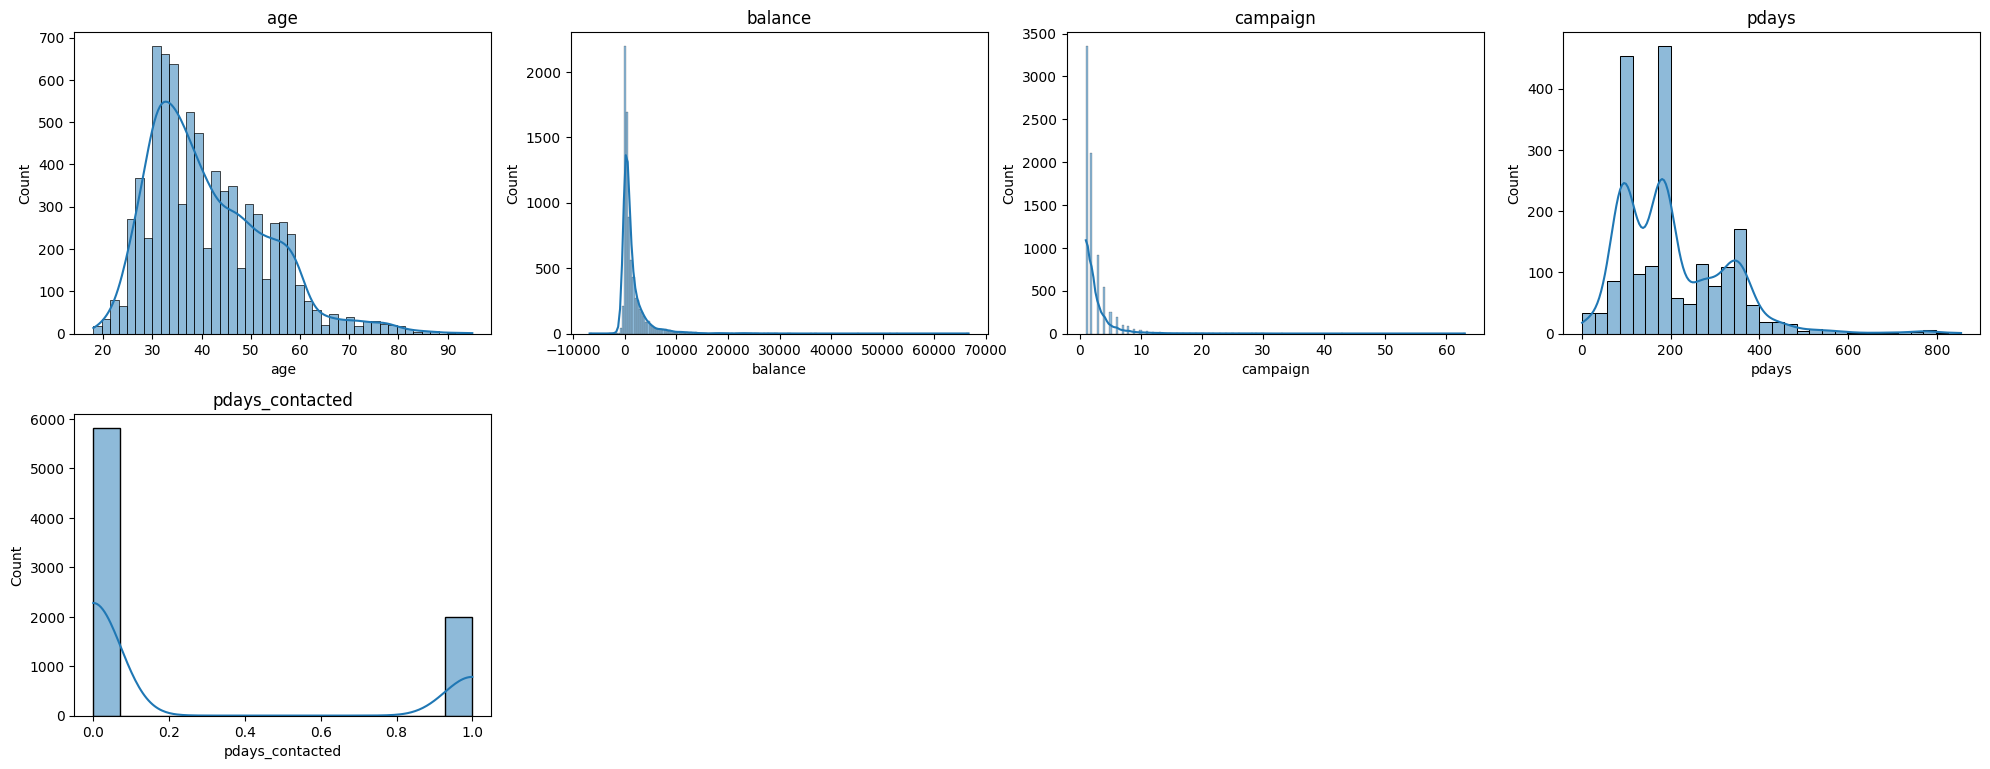

In [29]:
numerical_cols = df_cleaning.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 15))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_cleaning[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Dari visualisasi *boxplot* dan *histplot* untuk kolom numerik, terdapat adanya *outlier* yang signifikan pada beberapa fitur:

1.  **`balance`**: Terdapat *outlier* yang cukup ekstrem, baik pada sisi negatif (saldo terutang) maupun pada sisi positif (saldo sangat tinggi). Ini mengindikasikan bahwa beberapa nasabah memiliki kondisi finansial yang sangat berbeda dari rata-rata mayoritas.
2.  **`campaign`**: Kolom ini juga menunjukkan adanya *outlier* pada nilai-nilai yang tinggi, yang berarti ada beberapa nasabah yang dihubungi berkali-kali dalam satu kampanye. Kontak yang berlebihan ini bisa jadi merupakan *outlier* yang mempengaruhi efektivitas kampanye.
3.  **`pdays`**: nilai `pdays` yang tersisa yaitu, jumlah hari sejak kontak terakhir juga menunjukkan *outlier* pada rentang hari yang sangat panjang.

Keberadaan *outlier* ini memberikan informasi penting tentang variasi perilaku nasabah. Pada tahap ini, tidak dilakukan penghapusan atau transformasi *outlier* secara eksplisit, karena nilai-nilai tersebut dianggap sebagai informasi berharga dan beberapa akan ditangani secara implisit dalam proses *preprocessing* (seperti `pdays`) atau diharapkan dapat ditangani dengan baik oleh model *Machine Learning* yang robust terhadap *outlier*.

## EDA

In [30]:
df_eda = df_cleaning.copy()

### Uji Correlation

Spearman Correlation:


,age,balance,campaign,pdays,deposit_num
age,1.000000,0.101017,0.023083,-0.016447,0.000579
balance,0.101017,1.000000,-0.037065,-0.111119,0.167787
campaign,0.023083,-0.037065,1.000000,0.076205,-0.125054
pdays,-0.016447,-0.111119,0.076205,1.000000,-0.193704
deposit_num,0.000579,0.167787,-0.125054,-0.193704,1.000000


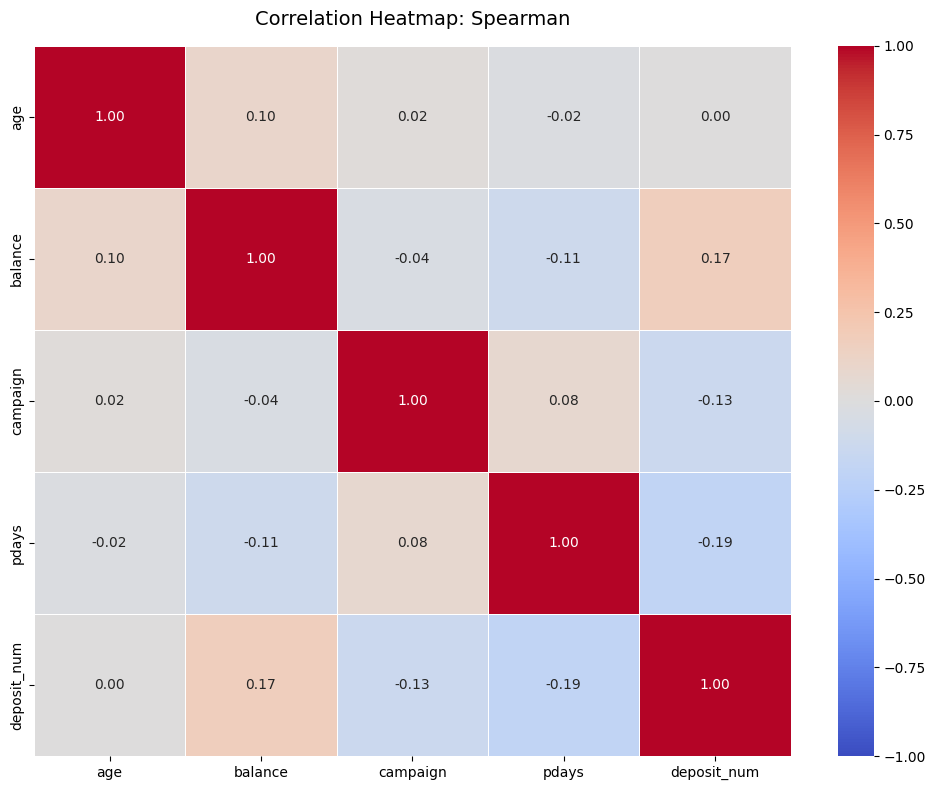

In [31]:
df_eda['deposit_num'] = df_eda['deposit'].apply(lambda x: 1 if x == 'yes' else 0)

spearman_corr = df_eda[[
    'age',
    'balance',
    'campaign',
    'pdays',
    'deposit_num'
]].corr(method='spearman')

print("Spearman Correlation:")
display(spearman_corr)

plt.figure(figsize=(10, 8))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Correlation Heatmap: Spearman', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Diputuskan menggunakan spearman dikarenakan distribusi data tidak normal. Berdasarkan tabel korelasi Spearman yang ditampilkan:

*   **`age` (usia) dan `deposit_num`**: Korelasi sangat rendah (0.000579), yang berarti usia memiliki sedikit atau bahkan tidak ada hubungan monoton dengan kemungkinan nasabah melakukan deposit.
*   **`balance` (saldo) dan `deposit_num`**: Terdapat korelasi positif yang lemah (0.167787). Ini menunjukkan bahwa nasabah dengan saldo yang lebih tinggi cenderung lebih mungkin untuk melakukan deposit.
*   **`campaign` (jumlah kontak dalam kampanye ini) dan `deposit_num`**: Terdapat korelasi negatif yang lemah (-0.125054). Ini mengindikasikan bahwa semakin banyak kontak yang dilakukan pada nasabah dalam kampanye ini, sedikit menurunkan kemungkinan mereka untuk melakukan deposit. Kontak yang berlebihan mungkin kontraproduktif.
*   **`pdays` (jumlah hari sejak terakhir dihubungi pada kampanye sebelumnya) dan `deposit_num`**: Terdapat korelasi negatif yang lemah hingga moderat (-0.193704). Ini menunjukkan bahwa semakin lama waktu sejak nasabah terakhir dihubungi pada kampanye sebelumnya (dan bukan yang 'never_contacted'), semakin kecil kemungkinan mereka untuk melakukan deposit.

In [32]:
# distribusi deposit
print("Distribusi kelas 'deposit':")
jumlah_deposit = df_eda['deposit'].value_counts()
proporsi_deposit = df_eda['deposit'].value_counts(normalize=True) * 100
display(pd.DataFrame({'Jumlah' : jumlah_deposit, 'Proporsi':proporsi_deposit}))

if proporsi_deposit['yes'] < 40 or proporsi_deposit['no'] < 40:
    print("\nTerjadi ketidakseimbangan data (imbalance data) pada kolom 'deposit'.")
else:
    print("\nDistribusi data pada kolom 'deposit' cukup seimbang")

Distribusi kelas 'deposit':


,Jumlah,Proporsi
deposit,,
no,4075,52.210122
yes,3730,47.789878



Distribusi data pada kolom 'deposit' cukup seimbang


In [33]:
deposit_counts = df_eda['deposit'].value_counts().reset_index()
deposit_counts.columns = ['Deposit Outcome', 'Count']

fig_deposit_outcome = px.pie(deposit_counts, names='Deposit Outcome', values='Count', title='<b>Distribution of Deposit Outcomes', color='Deposit Outcome', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_deposit_outcome.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textinfo='percent+label')
fig_deposit_outcome.update_layout(title_x=0.5, font_family="Times New Roman", title_font_family="Times New Roman")
fig_deposit_outcome.show()

Berdasarkan output di atas, distribusi hasil deposit cukup seimbang, dengan sekitar 52.21% nasabah tidak melakukan deposit (`no`) dan 47.79% nasabah melakukan deposit (`yes`). Hal ini menunjukkan bahwa tidak ada ketidakseimbangan data yang signifikan pada kolom target, sehingga model dapat belajar dari kedua kelas dengan baik.

### Uji Hipotesis

Akan dilakukan uji hipotesis untuk fitur-fitur yang memiliki korelasi terhadap deposit

#### Uji hipotesis untuk pdays (pdays_bin)

In [34]:
# tabel distribusi
print("Distribusi jumlah customer berdasarkan Pdays Contacted terhadap Deposit:")
jumlah_pdays_contacted = df_eda.groupby('pdays_contacted')['deposit'].value_counts()
proporsi_pdays_contacted = df_eda.groupby('pdays_contacted')['deposit'].value_counts(normalize=True)
display(pd.DataFrame({'Jumlah': jumlah_pdays_contacted, 'Proporsi': proporsi_pdays_contacted}))

# visualisasi bar chart
pdyas_deposit_counts = df_eda.groupby(['pdays_contacted', 'deposit']).size().reset_index(name='count')

fig_pdays_contacted = px.bar(pdyas_deposit_counts, x='pdays_contacted', y='count', color='deposit', barmode='group',
             text='count', title='<b>Customer Count by Pdays Contacted from Deposit Outcome',
             template='simple_white', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_pdays_contacted.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textposition='outside')
fig_pdays_contacted.update_layout(xaxis_title='Pdays Contacted',
                  yaxis_title='Number of Customers',
                  title_x=0.5,
                  font_family="Times New Roman",
                  title_font_family="Times New Roman")
display(fig_pdays_contacted.show())

Distribusi jumlah customer berdasarkan Pdays Contacted terhadap Deposit:


Jumlah  Proporsi
pdays_contacted deposit                  
0               no         3438  0.591840
                yes        2371  0.408160
1               yes        1359  0.680862
                no          637  0.319138

None

**Output Analisis `pdays_contacted` terhadap `deposit`:**


1.  **Kelompok `pdays_contacted = 0` (Belum Pernah Dihubungi):**
    *   **Jumlah:** 3438 nasabah tidak deposit (`no`) dan 2371 nasabah melakukan deposit (`yes`).
    *   Hanya sekitar **40.82%** dari nasabah di kelompok ini yang melakukan deposit. Sisanya, sekitar 59.18%, tidak melakukan deposit.
    *   Kelompok nasabah yang belum pernah dihubungi sebelumnya, memiliki tingkat konversi yang relatif rendah. Hal ini terjadi mungkin karena mereka belum familiar dengan bank atau produk deposito. Untuk mengkonversi nasabah di segmen ini membutuhkan upaya pemasaran yang lebih intensif atau penawaran yang lebih menarik untuk membangun kepercayaan dan minat awal.

2.  **Kelompok `pdays_contacted = 1` (Sudah Pernah Dihubungi):**
    *   **Jumlah:** 1359 nasabah melakukan deposit (`yes`) dan 637 nasabah tidak deposit (`no`).
    *   Sebanyak **68.09%** dari nasabah di kelompok ini melakukan deposit, jauh lebih tinggi dibandingkan kelompok yang belum pernah dihubungi. Hanya sekitar 31.91% yang tidak melakukan deposit.
    *   Nasabah yang sudah pernah dihubungi sebelumnya memiliki kemungkinan jauh lebih tinggi untuk melakukan deposit. Ini mengindikasikan bahwa riwayat kontak sebelumnya telah membangun *awareness* atau potensi minat pada produk bank.

In [35]:
# tabel distribusi
print("Distribusi jumlah customer berdasarkan Pdays Bin terhadap Deposit:")
jumlah_pdays_bin = df_eda.groupby('pdays_bin')['deposit'].value_counts()
proporsi_pdays_bin = df_eda.groupby('pdays_bin')['deposit'].value_counts(normalize=True)
display(pd.DataFrame({'Jumlah': jumlah_pdays_bin, 'Proporsi': proporsi_pdays_bin}))

# visualisasi bar chart
pdyas_bin_deposit_counts = df_eda.groupby(['pdays_bin', 'deposit']).size().reset_index(name='count')

fig_pdays_bin = px.bar(pdyas_bin_deposit_counts, x='pdays_bin', y='count', color='deposit', barmode='group',
             text='count', title='<b>Customer Count by Pdays Bin from Deposit Outcome',
             template='simple_white', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_pdays_bin.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textposition='outside')
fig_pdays_bin.update_layout(xaxis_title='Pdays Contacted',
                  yaxis_title='Number of Customers',
                  title_x=0.5,
                  font_family="Times New Roman",
                  title_font_family="Times New Roman")
display(fig_pdays_bin.show())

Distribusi jumlah customer berdasarkan Pdays Bin terhadap Deposit:


Jumlah  Proporsi
pdays_bin       deposit                  
≤7              no            6  0.545455
                yes           5  0.454545
8–30            yes          12  0.545455
                no           10  0.454545
31–90           yes         159  0.832461
                no           32  0.167539
91–180          yes         492  0.731055
                no          181  0.268945
181–365         yes         557  0.601512
                no          369  0.398488
>365            yes         134  0.774566
                no           39  0.225434
never_contacted no         3438  0.591840
                yes        2371  0.408160

None

**Output Analisis `pdays_bin` Terhadap `Deposit`:**

1.  **`never_contacted` (Tidak Pernah Dihubungi Sebelumnya):**
    *   **Proporsi Deposit (Yes): 40.82%** (Jumlah: 2371)
    *   **Proporsi Tidak Deposit (No): 59.18%** (Jumlah: 3438)
    *   Kelompok ini merupakan mayoritas nasabah. Tingkat konversi depositnya relatif rendah dibandingkan kelompok yang pernah dihubungi dan merespons positif. Ini menunjukkan tantangan untuk mengkonversi nasabah yang belum memiliki riwayat kontak positif sebelumnya.

2.  **`31–90` (Dihubungi antara 31-90 hari lalu):**
    *   **Proporsi Deposit (Yes): 83.25%** (Jumlah: 159)
    *   **Proporsi Tidak Deposit (No): 16.75%** (Jumlah: 32)
    *   Kelompok ini menunjukkan tingkat konversi deposit yang sangat tinggi. Nasabah yang dihubungi dalam rentang waktu ini memiliki kecenderungan sangat kuat untuk melakukan deposit. Ini mengindikasikan bahwa kontak yang relatif baru dan tidak terlalu lama mungkin sangat efektif.

3.  **`>365` (Dihubungi lebih dari 365 hari lalu):**
    *   **Proporsi Deposit (Yes): 77.46%** (Jumlah: 134)
    *   **Proporsi Tidak Deposit (No): 22.54%** (Jumlah: 39)
    *   Meskipun dihubungi cukup lama yang lalu, kelompok ini juga memiliki tingkat konversi yang sangat baik. Ini menunjukkan bahwa nasabah yang pernah merespons positif di masa lalu, bahkan jika sudah lama, masih memiliki potensi tinggi.

4.  **`91–180` (Dihubungi antara 91-180 hari lalu):**
    *   **Proporsi Deposit (Yes): 73.11%** (Jumlah: 492)
    *   **Proporsi Tidak Deposit (No): 26.89%** (Jumlah: 181)
    *   Tingkat konversi yang sangat baik juga terlihat pada kelompok ini, menegaskan pentingnya riwayat kontak sebelumnya.

5.  **`181–365` (Dihubungi antara 181-365 hari lalu):**
    *   **Proporsi Deposit (Yes): 60.15%** (Jumlah: 557)
    *   **Proporsi Tidak Deposit (No): 39.85%** (Jumlah: 369)
    *   Tingkat konversi masih baik di atas 50%, namun sedikit menurun dibandingkan kelompok dengan kontak lebih baru atau sangat lama. Ini mungkin menunjukkan efek memudar dari kampanye sebelumnya seiring berjalannya waktu.

6.  **`8–30` (Dihubungi antara 8-30 hari lalu):**
    *   **Proporsi Deposit (Yes): 54.55%** (Jumlah: 12)
    *   **Proporsi Tidak Deposit (No): 45.45%** (Jumlah: 10)
    *   Tingkat konversi cukup baik, meskipun data jumlah nasabahnya relatif kecil. Ini mengindikasikan bahwa kontak yang sangat baru masih efektif.

7.  **`≤7` (Dihubungi dalam 7 hari terakhir):**
    *   **Proporsi Deposit (Yes): 45.45%** (Jumlah: 5)
    *   **Proporsi Tidak Deposit (No): 54.55%** (Jumlah: 6)
    *   Dengan jumlah sampel yang sangat kecil, proporsi ini menunjukkan konversi yang sedikit di bawah 50%. Sulit untuk menarik kesimpulan kuat, namun dapat mengindikasikan bahwa kontak yang terlalu sering atau terlalu baru mungkin tidak selalu optimal jika tidak diimbangi dengan kualitas kontak.

**Summary dari Insight tersebut:**

*   **Riwayat Kontak Positif Penting:** Nasabah yang pernah dihubungi pada kampanye sebelumnya (`pdays_bin` selain `never_contacted`) cenderung memiliki tingkat konversi deposit yang jauh lebih tinggi dibandingkan dengan mereka yang belum pernah dihubungi. Kelompok **`31–90` hari dan `>365` hari** menunjukkan performa terbaik meskipun jumlahnya tidak cukup banyak.
*   **Prioritaskan Nasabah dengan Riwayat Kontak:** Strategi pemasaran sebaiknya lebih memprioritaskan nasabah yang sudah memiliki riwayat kontak positif.
*   **Tantangan untuk `never_contacted`:** Mengkonversi nasabah yang belum pernah dihubungi sebelumnya merupakan tantangan terbesar dan mungkin memerlukan strategi *campaign* yang berbeda atau penawaran yang lebih menarik.

In [36]:
# Buat tabel kontingensi
contingency_table = pd.crosstab(df_eda['pdays_bin'], df_eda['deposit_num'])

# Lakukan uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test antara Kelompok Umur dan Hasil Deposit:")
print(f"Statistik Chi-Square: {chi2:.4f}")
print(f"P Value: {p_value}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'pdays' dan 'deposit'.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada hubungan yang signifikan antara 'pdays' dan 'deposit'.")

Chi-Square Test antara Kelompok Umur dan Hasil Deposit:
Statistik Chi-Square: 500.4852
P Value: 6.6098164464350534e-105

Karena nilai P (6.6098164464350534e-105) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'pdays' dan 'deposit'.


Kesimpulan dari hasil uji hipotesis:

Karena nilai P (6.61e-105) jauh lebih kecil dari tingkat signifikansi (0.05), maka **menolak Hipotesis Nol**. Ini berarti **ada hubungan yang signifikan secara statistik antara kategori `pdays_bin` dan keputusan nasabah untuk melakukan deposit (`deposit_num`)**.



#### Uji hipotesis untuk poutcome

In [37]:
# tabel distribusi
print("Distribusi jumlah customer berdasarkan poutcome terhadap Deposit:")
jumlah_poutcome = df_eda.groupby('poutcome')['deposit'].value_counts()
proporsi_poutcome = df_eda.groupby('poutcome')['deposit'].value_counts(normalize=True)
display(pd.DataFrame({'Jumlah': jumlah_poutcome, 'Proporsi': proporsi_poutcome}))

poutcome_deposit_counts = df_eda.groupby(['poutcome', 'deposit']).size().reset_index(name='count')

# visualisasi bar chart
fig_poutcome = px.bar(poutcome_deposit_counts, x='poutcome', y='count', color='deposit', barmode='group',
             text='count', title='<b>Customer Count by Campaign Outcome from Deposit Outcome',
             template='simple_white', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_poutcome.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textposition='outside')
fig_poutcome.update_layout(xaxis_title='poutcome',
                  yaxis_title='Number of Customers',
                  title_x=0.5,
                  font_family="Times New Roman",
                  title_font_family="Times New Roman")
display(fig_poutcome.show())

Distribusi jumlah customer berdasarkan poutcome terhadap Deposit:


Jumlah  Proporsi
poutcome deposit                  
failure  yes         661  0.536091
         no          572  0.463909
success  yes         696  0.914586
         no           65  0.085414
unknown  no         3438  0.591637
         yes        2373  0.408363

None

Berikut adalah penjelasan dari hasil `poutcome` berdasarkan analisis sebelumnya:

Dari hasil output kolom `poutcome` terhadap `deposit`, kita bisa mendapatkan insight sebagai berikut:

1.  **Kategori `failure`**: Ada sedikit lebih banyak nasabah yang melakukan deposit (yes 53.61%) dibandingkan yang tidak (no 46.39%). Ini menunjukkan bahwa nasabah yang sebelumnya gagal didekati masih memiliki potensi yang cukup baik untuk dipertimbangkan kembali.
2.  **Kategori `success`**: Ini merupakan kategori yang paling menjanjikan karena hampir semua nasabah yang di kampanye sebelumnya melakukan deposit yaitu sebesar 91.5% dan yang tidak hanya sebesar 8.54%. Ini menunjukkan bahwa nasabah yang pernah merespons positif di masa lalu memiliki kemungkinan yang sangat tinggi untuk melakukan deposit kembali.
3.  **Kategori `unknown`**: Pada kategori ini untuk nasabah dengan hasil kampanye sebelumnya yang tidak melakukan deposit sebesar 59.19% dengan jumlah 3444 nasabah, dan hanya 40.81% dengan jumlah 2375 nasabah yang melakukan deposit. Ini mengindikasikan bahwa nasabah yang informasinya kurang lengkap atau belum pernah didekati secara efektif sebelumnya, cenderung lebih sulit untuk diajak deposit.

**Summary dari Insight tersebut:**

Nasabah dengan riwayat `success` sangat berharga, sementara mereka yang `failure` masih memiliki potensi signifikan. Kategori `unknown` adalah yang paling menantang dan memerlukan pendekatan yang berbeda atau fokus pada pengumpulan data sebelum menargetkan mereka secara aktif.

In [38]:
# Buat tabel kontingensi
contingency_table = pd.crosstab(df_eda['poutcome'], df_eda['deposit_num'])

# Lakukan uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test antara Kelompok Umur dan Hasil Deposit:")
print(f"Statistik Chi-Square: {chi2:.4f}")
print(f"P Value: {p_value}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'poutcome' dan 'deposit'.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada hubungan yang signifikan antara 'poutcome' dan 'deposit'.")

Chi-Square Test antara Kelompok Umur dan Hasil Deposit:
Statistik Chi-Square: 710.9569
P Value: 4.146371348399343e-155

Karena nilai P (4.146371348399343e-155) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'poutcome' dan 'deposit'.


Kesimpulan dari hasil uji hipotesis:

Karena nilai P (4.15e-155) jauh lebih kecil dari tingkat signifikansi (0.05), maka **menolak Hipotesis Nol**. Ini berarti **ada hubungan yang signifikan secara statistik antara kategori `poutcome` dan keputusan nasabah untuk melakukan deposit (`deposit_num`)**.

#### Uji hipotesis untuk Contact

In [39]:
# tabel distribusi
print("Distribusi jumlah customer berdasarkan contact terhadap Deposit:")
jumlah_contact = df_eda.groupby('contact')['deposit'].value_counts()
proporsi_contact = df_eda.groupby('contact')['deposit'].value_counts(normalize=True)

contact_deposit_counts = df_eda.groupby(['contact', 'deposit']).size().reset_index(name='count')

# visualisasi bar chart
fig_contact = px.bar(contact_deposit_counts, x='contact', y='count', color='deposit', barmode='group',
             text='count', title='<b>Customer Count by Contact from Deposit Outcome',
             template='simple_white', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_contact.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textposition='outside')
fig_contact.update_layout(xaxis_title='contact',
                  yaxis_title='Number of Customers',
                  title_x=0.5,
                  font_family="Times New Roman",
                  title_font_family="Times New Roman")

display(pd.DataFrame({'Jumlah': jumlah_contact, 'Proporsi': proporsi_contact}))
display(fig_contact.show())

Distribusi jumlah customer berdasarkan contact terhadap Deposit:


Jumlah  Proporsi
contact   deposit                  
cellular  yes        3099  0.551129
          no         2524  0.448871
other     no         1275  0.779340
          yes         361  0.220660
telephone no          276  0.505495
          yes         270  0.494505

None

Berdasarkan hasil output kolom `contact` terhadap `deposit`, kita bisa mendapatkan insight sebagai berikut:

1.  **Contact `cellular`**: Ini adalah metode kontak yang paling umum dan paling efektif. Sebanyak 55.11% nasabah yang dihubungi melalui `cellular` melakukan deposit, sedangkan 44.89% tidak. Ini menunjukkan tingkat konversi yang baik melalui kontak seluler.

2.  **Contact `other`**: Kategori ini menunjukkan tingkat konversi yang jauh lebih rendah. Hanya sekitar 22.07% nasabah yang dihubungi melalui metode 'other' melakukan deposit, sementara 77.93% tidak. Hal ini mengindikasikan bahwa metode kontak 'other' (yang kemungkinan mencakup 'unknown' dari data awal) kurang efektif dalam mendorong nasabah untuk melakukan deposit.

3.  **Contact `telephone`**: Tingkat konversi untuk kontak telepon cukup seimbang, dengan 49.45% nasabah melakukan deposit dan 50.55% tidak. Meskipun sedikit di bawah `cellular`, metode ini masih lebih baik dibandingkan `other`.

**Summary dari insight tersebut:**

**Kontak `cellular`** adalah saluran komunikasi paling menjanjikan untuk kampanye deposit, dengan tingkat keberhasilan tertinggi. **Kontak `telephone`** memiliki potensi sedang, hampir seimbang antara berhasil dan tidak. **Kontak `other`** adalah yang paling tidak efektif karena sebagian besar nasabah cenderung tidak melakukan deposit  dan mungkin perlu dihindari atau ditinjau ulang strateginya.

In [40]:
# Buat tabel kontingensi
contingency_table = pd.crosstab(df_eda['contact'], df_eda['deposit_num'])

# Lakukan uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test antara Kelompok Umur dan Hasil Deposit:")
print(f"Statistik Chi-Square: {chi2:.4f}")
print(f"P Value: {p_value}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'contact' dan 'deposit'.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada hubungan yang signifikan antara 'contact' dan 'deposit'.")

Chi-Square Test antara Kelompok Umur dan Hasil Deposit:
Statistik Chi-Square: 555.3331
P Value: 2.5760598282825027e-121

Karena nilai P (2.5760598282825027e-121) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'contact' dan 'deposit'.


Kesimpulan dari hasil uji hipotesis:

Karena nilai P (2.57e-121) jauh lebih kecil dari tingkat signifikansi (0.05), maka **menolak Hipotesis Nol**. Ini berarti **ada hubungan yang signifikan secara statistik antara kategori `contact` dan keputusan nasabah untuk melakukan deposit (`deposit_num`)**.

#### Uji hipotesis untuk job

In [41]:
# tabel distribusi
print("Distribusi jumlah customer berdasarkan job terhadap Deposit:")
jumlah_job = df_eda.groupby('job')['deposit'].value_counts()
proporsi_job = df_eda.groupby('job')['deposit'].value_counts(normalize=True)
display (pd.DataFrame({'Jumlah': jumlah_job, 'Proporsi': proporsi_job}))

job_deposit_counts = df_eda.groupby(['job', 'deposit']).size().reset_index(name='count')

# visualisasi bar chart
fig_job = px.bar(job_deposit_counts, x='job', y='count', color='deposit', barmode='group',
             text='count', title='<b>Customer Count by Job from Deposit Outcome',
             template='simple_white', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_job.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textposition='outside')
fig_job.update_layout(xaxis_title='Job',
                  yaxis_title='Number of Customers',
                  title_x=0.5,
                  font_family="Times New Roman",
                  title_font_family="Times New Roman")
display(fig_job.show())

Distribusi jumlah customer berdasarkan job terhadap Deposit:


Jumlah  Proporsi
job           deposit                  
admin         no          492  0.525641
              yes         444  0.474359
blue-collar   no          840  0.625465
              yes         503  0.374535
entrepreneur  no          142  0.601695
              yes          94  0.398305
housemaid     no          112  0.608696
              yes          72  0.391304
management    yes         913  0.510341
              no          876  0.489659
other         no           28  0.518519
              yes          26  0.481481
retired       yes         365  0.675926
              no          175  0.324074
self-employed no          153  0.546429
              yes         127  0.453571
services      no          398  0.604863
              yes         260  0.395137
student       yes         184  0.744939
              no           63  0.255061
technician    no          694  0.538402
              yes         595  0.461598
unemployed    yes         147  0.590361
              no          102  0.409639

None

Berikut adalah penjelasan rinci dan *insight* dari output yang menunjukkan hubungan antara pekerjaan (*job*) dan keputusan deposit nasabah:

Output di atas menampilkan jumlah (`Jumlah`) dan proporsi (`Proporsi`) nasabah yang melakukan deposit (`yes`) atau tidak (`no`) untuk setiap kategori pekerjaan. Proporsi ini sangat penting untuk memahami pekerjaan mana yang lebih responsif terhadap tawaran deposit.

**Analisis Pekerjaan (Job) Terhadap Deposit:**

1.  **Student (Mahasiswa):**
    *   **Proporsi Deposit (Yes): 74.49%** (Jumlah: 184)
    *   **Proporsi Deposit (No): 25.51%** (Jumlah: 63)
    *   Mahasiswa memiliki tingkat konversi deposit tertinggi. Ini menunjukkan bahwa mereka adalah segmen yang sangat responsif terhadap kampanye deposit. Mungkin karena mereka mencari cara untuk menyimpan uang atau memanfaatkan penawaran khusus untuk pelajar.

2.  **Retired (Pensiunan):**
    *   **Proporsi Deposit (Yes): 67.59%** (Jumlah: 365)
    *   **Proporsi Deposit (No): 32.41%** (Jumlah: 175)
    *   Pensiunan juga menunjukkan tingkat konversi yang sangat tinggi. Hal ini mungkin karena mereka memiliki tabungan atau pendapatan tetap dari pensiun dan mencari investasi yang aman dengan bunga tetap.

3.  **Unemployed (Pengangguran):**
    *   **Proporsi Deposit (Yes): 59.04%** (Jumlah: 147)
    *   **Proporsi Deposit (No): 40.94%** (Jumlah: 102)
    *   Meskipun pengangguran, proporsi deposit mereka cukup tinggi. Ini bisa mengindikasikan mencari cara untuk mengamankan dana yang ada.

4.  **Management (Manajemen):**
    *   **Proporsi Deposit (Yes): 51.03%** (Jumlah: 913)
    *   **Proporsi Deposit (No): 48.97%** (Jumlah: 876)
    *   Nasabah dengan pekerjaan di bidang manajemen memiliki sedikit lebih banyak kemungkinan untuk deposit. Mereka cenderung memiliki pendapatan yang lebih stabil dan mungkin lebih sadar akan pentingnya investasi dengan resiko rendah.

5.  **Other (Lain-lain):**
    *   **Proporsi Deposit (Yes): 48.15%** (Jumlah: 26)
    *   **Proporsi Deposit (No): 51.85%** (Jumlah: 28)
    *   Kategori ini menunjukkan proporsi deposit yang hampir seimbang. Mengingat 'other' merupakan pekerjaan yang tidak terklasifikasi, sulit untuk menarik kesimpulan yang kuat tanpa informasi lebih lanjut.

6.  **Admin. (Administrasi):**
    *   **Proporsi Deposit (Yes): 47.44%** (Jumlah: 444)
    *   **Proporsi Deposit (No): 32.41%** (Jumlah: 492)
    *   Nasabah di bidang administrasi memiliki proporsi deposit yang cukup signifikan, sedikit di bawah 50%.

7.  **Self-employed (Wiraswasta):**
    *   **Proporsi Deposit (Yes): 45.36%** (Jumlah: 127)
    *   **Proporsi Deposit (No): 54.64%** (Jumlah: 153)
    *   Wiraswasta memiliki kecenderungan deposit yang moderat, di bawah rata-rata deposit.

8.  **Technician (Teknisi):**
    *   **Proporsi Deposit (Yes): 46.16%** (Jumlah: 595)
    *   **Proporsi Deposit (No): 53.84%** (Jumlah: 694)
    *   Tingkat deposit untuk teknisi sedikit di bawah rata-rata keseluruhan, menunjukkan potensi yang perlu dipertimbangkan dengan cermat.

9.  **Entrepreneur (Wirausaha):**
    *   **Proporsi Deposit (Yes): 39.83%** (Jumlah: 94)
    *   **Proporsi Deposit (No): 60.17%** (Jumlah: 142)
    *   Wirausaha memiliki tingkat deposit yang relatif lebih rendah, di bawah 40%. Mungkin kategori ini lebih suka menginvestasikan dana mereka kembali ke bisnis.

10. **Housemaid (Pembantu Rumah Tangga):**
    *   **Proporsi Deposit (Yes): 39.13%** (Jumlah: 72)
    *   **Proporsi Deposit (No): 60.87%** (Jumlah: 112)
    *   Tingkat deposit untuk pembantu rumah tangga juga rendah, mungkin karena keterbatasan pendapatan.

11. **Services (Layanan):**
    *   **Proporsi Deposit (Yes): 39.51%** (Jumlah: 260)
    *   **Proporsi Deposit (No): 60.49%** (Jumlah: 398)
    *   Nasabah di sektor layanan memiliki tingkat deposit yang rendah, serupa dengan wirausaha dan pembantu rumah tangga.

12. **Blue-collar (Pekerja Kasar):**
    *   **Proporsi Deposit (Yes): 37.45%** (Jumlah: 503)
    *   **Proporsi Deposit (No): 62.55%** (Jumlah: 840)
    *   Pekerja kasar memiliki tingkat konversi deposit terendah. Ini menunjukkan bahwa mereka adalah kelompok yang paling sulit untuk diyakinkan agar melakukan deposit, kemungkinan karena pendapatan yang lebih rendah dengan prioritas pengeluaran yang berbeda.

**Summary dari insight tersebut:**

*   Fokus utama kampanye harus pada **Student**, **Retire**, dan **Unemployee**, karena mereka memiliki probabilitas deposit tertinggi.
*   Kelompok seperti **Management** dan **Admin** masih memiliki potensi, tetapi mungkin memerlukan strategi yang lebih ditargetkan.
*   **Tantangan:** Kategori seperti **Blue-collar**, **Services**, **Entrepreneur**, dan **Housemaid** menunjukkan tingkat konversi yang jauh lebih rendah. Kampanye untuk kelompok ini mungkin memerlukan pendekatan yang sangat berbeda atau resources yang lebih besar untuk mencapai hasil yang sama.

In [42]:
# Buat tabel kontingensi
contingency_table = pd.crosstab(df_eda['job'], df_eda['deposit_num'])

# Lakukan uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test antara Pekerjaan dan Hasil Deposit:")
print(f"Statistik Chi-Square: {chi2:.4f}")
print(f"P Value: {p_value}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'pekerjaan' dan 'deposit'.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada hubungan yang signifikan antara 'pekerjaan' dan 'deposit'.")

Chi-Square Test antara Pekerjaan dan Hasil Deposit:


Statistik Chi-Square: 264.8102
P Value: 2.1968721164105395e-50

Karena nilai P (2.1968721164105395e-50) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'pekerjaan' dan 'deposit'.


Kesimpulan dari hasil uji hipotesis:

Karena nilai P (2.20e-50) jauh lebih kecil dari tingkat signifikansi (0.05), maka **menolak Hipotesis Nol**. Ini berarti **ada hubungan yang signifikan secara statistik antara kategori `job` dan keputusan nasabah untuk melakukan deposit (`deposit_num`)**.

#### Uji hipotesis untuk months

In [43]:
# tabel distribusi
print("Distribusi jumlah customer berdasarkan months terhadap Deposit:")


month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

jumlah_month = df_eda.groupby('month')['deposit'].value_counts()
proporsi_month = df_eda.groupby('month')['deposit'].value_counts(normalize=True)

df_month_summary = pd.DataFrame({'Jumlah': jumlah_month, 'Proporsi': proporsi_month})
df_month_summary.index = df_month_summary.index.set_levels(pd.Categorical(df_month_summary.index.levels[0], categories=month_order, ordered=True), level='month')

# Urutkan dataframe
df_month_summary = df_month_summary.sort_index(level='month')

display(df_month_summary)

job_deposit_counts = df_eda.groupby(['job', 'deposit']).size().reset_index(name='count')

Distribusi jumlah customer berdasarkan months terhadap Deposit:


Jumlah  Proporsi
month deposit                  
jan   no          128  0.563877
      yes          99  0.436123
feb   no          233  0.436330
      yes         301  0.563670
mar   no           22  0.110553
      yes         177  0.889447
apr   no          247  0.373112
      yes         415  0.626888
may   no         1315  0.666498
      yes         658  0.333502
jun   no          472  0.550758
      yes         385  0.449242
jul   no          620  0.591039
      yes         429  0.408961
aug   no          586  0.542091
      yes         495  0.457909
sep   no           34  0.160377
      yes         178  0.839623
oct   no           43  0.150350
      yes         243  0.849650
nov   no          367  0.558600
      yes         290  0.441400
dec   no            8  0.117647
      yes          60  0.882353

**Analisis Bulan (Month) Terhadap Deposit:**

1.  **Bulan dengan Tingkat Konversi Deposit Tertinggi:** Bulan **Maret (88.94%)**, **Desember (88.23%)**, **Oktober (84.96%)**, dan **September (83.96%)** menunjukkan proporsi nasabah yang melakukan deposit yang sangat tinggi. Ini mengindikasikan bahwa kampanye yang dilakukan di bulan-bulan ini sangat efektif dalam meyakinkan nasabah untuk berinvestasi.

2.  **Bulan dengan Tingkat Konversi Deposit Terendah:** Sebaliknya, bulan **Mei (33.35%)**, **Juli (40.89%)**, **Januari (43.61%)**, **November (44.14%)**, **Juni (44.92%)**, dan **Agustus (45.79%)** memiliki proporsi deposit 'yes' yang relatif rendah.

3.  **Insight menarik dari hasil ini**, bulan-bulan dengan jumlah kontak terbanyak (misalnya, Mei dengan 1973 kontak, Juli dengan 1049, atau Agustus dengan 1081) justru memiliki tingkat konversi yang rendah. Sebaliknya, bulan-bulan dengan jumlah kontak paling sedikit (misalnya, Desember dengan 68 kontak atau Maret dengan 199 kontak) memiliki tingkat konversi yang sangat tinggi.

4. Hasil kontradiksi ini menunjukkan bahwa bank perlu mengevaluasi strategi kampanye di setiap bulan. Di bulan-bulan dengan tingkat konversi rendah namun volume kontak tinggi, pendekatan yang digunakan mungkin kurang tepat atau nasabah kurang responsif terhadap penawaran. Sementara itu, di bulan-bulan dengan tingkat konversi tinggi, ada peluang besar untuk meningkatkan total deposit jika volume kontak dapat ditingkatkan.

In [44]:
# Buat tabel kontingensi
contingency_table = pd.crosstab(df_eda['month'], df_eda['deposit_num'])

# Lakukan uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test antara Pekerjaan dan Hasil Deposit:")
print(f"Statistik Chi-Square: {chi2:.4f}")
print(f"P Value: {p_value}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'Bulan' dan 'deposit'.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada hubungan yang signifikan antara 'Bulan' dan 'deposit'.")

Chi-Square Test antara Pekerjaan dan Hasil Deposit:
Statistik Chi-Square: 718.3888
P Value: 6.15795022487818e-147

Karena nilai P (6.15795022487818e-147) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'Bulan' dan 'deposit'.


Kesimpulan dari hasil uji hipotesis:

Karena nilai P (6.16e-147) jauh lebih kecil dari tingkat signifikansi (0.05), maka **menolak Hipotesis Nol**. Ini berarti **ada hubungan yang signifikan secara statistik antara kategori `month` dan keputusan nasabah untuk melakukan deposit (`deposit_num`)**.

#### Uji hipotesis untuk age group

In [45]:
# Tabel distribusi
print("Distribusi jumlah customer berdasarkan age group terhadap Deposit:")

jumlah_age_group = df_eda.groupby('age_group')['deposit'].value_counts()
proporsi_age = df_eda.groupby('age_group')['deposit'].value_counts(normalize=True)
display(pd.DataFrame({'Jumlah': jumlah_age_group, 'Proporsi': proporsi_age}))

age_deposit_counts = df_eda.groupby(['age_group', 'deposit']).size().reset_index(name='count')

# Visualisasi bar chart
fig_age = px.bar(age_deposit_counts, x='age_group', y='count', color='deposit', barmode='group',
             title='<b>Age Group by Deposit Outcome', template='simple_white',
             color_discrete_sequence=px.colors.qualitative.Pastel, text='count')

fig_age.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textposition='outside')
fig_age.update_layout(xaxis_title='Age Group', yaxis_title='Number of Customers',
                  title_x=0.5, font_family="Times New Roman",
                  title_font_family="Times New Roman")
display(fig_age.show())

Distribusi jumlah customer berdasarkan age group terhadap Deposit:


Jumlah  Proporsi
age_group          deposit                  
Young Adults       yes         210  0.684039
                   no           97  0.315961
Early Adulthood    no         2172  0.537890
                   yes        1866  0.462110
Middle-Aged Adults no         1728  0.572185
                   yes        1292  0.427815
Older Adults       yes         280  0.838323
                   no           54  0.161677
Seniors            yes          82  0.773585
                   no           24  0.226415

None

**Analisis Kelompok Usia (Age Group) Terhadap Deposit:**

1.  **Older Adults (61-75 tahun):**
    *   **Proporsi Deposit (Yes): 83.83%** (Jumlah: 280)
    *   Kelompok usia ini memiliki tingkat konversi deposit tertinggi. Ini menunjukkan bahwa mereka adalah segmen yang sangat responsif terhadap kampanye deposit. Kemungkinan di umurnya mereka memiliki dana pensiun atau tabungan yang ingin diinvestasikan dengan aman.

2.  **Seniors (76-95 tahun):**
    *   **Proporsi Deposit (Yes): 77.36%** (Jumlah: 82)
    *   Sama seperti Older Adults, kelompok Seniors juga menunjukkan tingkat konversi yang sangat tinggi.

3.  **Young Adults (18-25 tahun):**
    *   **Proporsi Deposit (Yes): 68.40%** (Jumlah: 210)
    *   Kelompok usia muda ini juga memiliki tingkat deposit yang tinggi. Ini bisa jadi karena mereka mulai menabung, memiliki target keuangan jangka pendek, atau tertarik dengan penawaran yang sesuai untuk nasabah baru.

4.  **Early Adulthood (26-40 tahun):**
    *   **Proporsi Deposit (Yes): 46.21%** (Jumlah: 1866)
    *   Kelompok ini merupakan mayoritas nasabah namun memiliki proporsi deposit yang sedikit di bawah 50%. Ini menunjukkan potensi yang cukup besar tetapi mungkin memerlukan strategi yang lebih disesuaikan untuk meningkatkan konversi.

5.  **Middle-Aged Adults (41-60 tahun):**
    *   **Proporsi Deposit (Yes): 42.78%** (Jumlah: 1292)
    *   Tingkat deposit untuk kelompok usia ini sedikit lebih rendah dari Early Adulthood. Meskipun jumlahnya signifikan, proporsi depositnya menunjukkan bahwa mereka mungkin lebih berhati-hati atau memiliki prioritas keuangan lain.

**Ringkasan Insight Penting:**

*   Fokus utama kampanye harus pada **Older Adults**, **Seniors**, dan **Young Adults** karena mereka memiliki probabilitas deposit tertinggi. Kelompok ini menunjukkan respons paling positif terhadap penawaran deposit.
*   Kelompok **Early Adulthood** dan **Middle-Aged Adults** merupakan segmen yang besar dan memiliki potensi yang cukup baik, tetapi mungkin memerlukan strategi penawaran yang lebih menarik atau disesuaikan dengan kebutuhan dan kondisi finansial mereka.

In [46]:
# Buat tabel kontingensi
contingency_table = pd.crosstab(df_eda['age_group'], df_eda['deposit_num'])

# Lakukan uji Chi-Square
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test antara Kelompok Umur dan Hasil Deposit:")
print(f"Statistik Chi-Square: {chi2:.4f}")
print(f"P Value: {p_value}")

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'kelompok umur' dan 'deposit'.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada hubungan yang signifikan antara 'kelompok umur' dan 'deposit'.")

Chi-Square Test antara Kelompok Umur dan Hasil Deposit:
Statistik Chi-Square: 297.7171
P Value: 3.366938719390758e-63

Karena nilai P (3.366938719390758e-63) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada hubungan yang signifikan secara statistik antara 'kelompok umur' dan 'deposit'.


Kesimpulan dari hasil uji hipotesis:

Karena nilai P (3.36e-63) jauh lebih kecil dari tingkat signifikansi (0.05), maka **menolak Hipotesis Nol**. Ini berarti **ada hubungan yang signifikan secara statistik antara kategori `kelompok umur` dan keputusan nasabah untuk melakukan deposit (`deposit_num`)**.

#### Uji hipotesis untuk balance

In [47]:
mean_balance_by_job_deposit = df_eda.groupby(['job', 'deposit'])['balance'].mean().reset_index()
mean_balance_by_job_deposit['balance_formatted'] = mean_balance_by_job_deposit['balance'].apply(lambda x: f'{x:.2f}')

fig_mean_balance_by_job = px.bar(mean_balance_by_job_deposit, x='job', y='balance', color='deposit', barmode='group',
             text='balance_formatted', title='<b>Average Balance by Job from Deposit Outcome',
             template='simple_white', color_discrete_sequence=px.colors.qualitative.Pastel)

fig_mean_balance_by_job.update_traces(marker=dict(line=dict(color='#000000', width=1.2)), textposition='outside')
fig_mean_balance_by_job.update_layout(xaxis_title='Job', yaxis_title='Average Balance',
                  title_x=0.5, font_family="Times New Roman",
                  title_font_family="Times New Roman", yaxis_tickformat=".2f")
fig_mean_balance_by_job.show()

Berikut adalah penjelasan dari rata-rata saldo berdasarkan pekerjaan dan hasil deposit, seperti yang terlihat pada grafik:

*   Secara Umum Untuk hampir semua kategori pekerjaan, **nasabah yang melakukan deposit (`deposit = 'yes'`) cenderung memiliki rata-rata saldo yang lebih tinggi dibandingkan dengan nasabah yang tidak melakukan deposit (`deposit = 'no'`)**.

*   **Kategori dengan Rata-rata Saldo Deposit Tinggi:**
    *   **Retired (Pensiunan):** Rata-rata saldo nasabah pensiunan yang melakukan deposit sangat tinggi, mencapai sekitar 2936. Ini jauh lebih tinggi dibandingkan pensiunan yang tidak deposit sekitar 2583. Ini mengindikasikan bahwa pensiunan dengan saldo lebih besar cenderung lebih aktif dalam berinvestasi deposit.
    *   **Management (Manajemen):** Nasabah di sektor manajemen yang melakukan deposit juga memiliki rata-rata saldo yang signifikan, sekitar 2229, dibandingkan dengan yang tidak deposit (sekitar $1622).
    *   **Student (Mahasiswa):** Meskipun tidak setinggi retired atau management, mahasiswa yang deposit memiliki rata-rata saldo sekitar 1670, lebih tinggi dari yang tidak deposit (sekitar 1212).

*   **Kategori dengan Perbedaan Rata-rata Saldo Paling Jelas:**
    *   **Retired, Management, Student, Entrepreneur, Self-employed, Technician, dan Admin:** Pada kategori ini, rata-rata saldo nasabah yang melakukan deposit secara konsisten lebih tinggi daripada yang tidak melakukan deposit, menunjukkan korelasi positif antara saldo yang lebih tinggi dan kecenderungan untuk berdeposit.

*   **Kategori dengan Rata-rata Saldo Deposit Rendah (namun tetap lebih tinggi jika deposit):**
    *   **Blue-collar, Services, Housemaid, dan Unemployed:** Walaupun rata-rata saldonya lebih rendah secara keseluruhan, tren yang sama tetap terlihat: nasabah di kategori ini yang melakukan deposit tetap memiliki rata-rata saldo yang sedikit lebih tinggi daripada yang tidak. Misalnya, pekerja 'blue-collar' yang deposit memiliki rata-rata saldo 1301, sedangkan yang tidak deposit 1199.

**Kesimpulan:**

Grafik ini memperkuat temuan sebelumnya bahwa **saldo (`balance`) merupakan faktor penting dalam keputusan nasabah untuk melakukan deposit**. Nasabah dengan rata-rata saldo yang lebih tinggi, terlepas dari pekerjaannya, lebih cenderung untuk berinvestasi dalam produk deposit berjangka. Bank dapat menggunakan insight ini untuk menargetkan nasabah dengan saldo yang lebih tinggi atau menawarkan insentif khusus kepada nasabah dengan saldo menengah untuk mendorong mereka melakukan deposit.

In [48]:
# Memisahkan data 'balance' berdasarkan 'deposit_num'
balance_no_deposit = df_eda[df_eda['deposit_num'] == 0]['balance']
balance_with_deposit = df_eda[df_eda['deposit_num'] == 1]['balance']

# Melakukan Uji Mann-Whitney U
u_statistic, p_value = mannwhitneyu(balance_no_deposit, balance_with_deposit, alternative='two-sided')

print("Mann-Whitney U Test antara Saldo (balance) dan Hasil Deposit (deposit_num):")
print(f"U-Statistic: {u_statistic:.4f}")
print(f"P-value: {p_value}")

# Interpretasi P-value
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada perbedaan yang signifikan secara statistik dalam 'saldo' antara kelompok yang melakukan deposit dan yang tidak.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada perbedaan yang signifikan secara statistik dalam 'saldo' antara kelompok yang melakukan deposit dan yang tidak.")

Mann-Whitney U Test antara Saldo (balance) dan Hasil Deposit (deposit_num):
U-Statistic: 6126245.5000
P-value: 1.0499892842575338e-49

Karena nilai P (1.0499892842575338e-49) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada perbedaan yang signifikan secara statistik dalam 'saldo' antara kelompok yang melakukan deposit dan yang tidak.


**Hasil Uji Hipotesis antara Kolom `balance` dan `deposit_num`:**

Berdasarkan Uji Mann-Whitney U antara variabel `balance` (saldo) dan `deposit_num` (hasil deposit):

Karena nilai P (`1.05e-49`) jauh lebih kecil dari tingkat signifikansi (`0.05`), maka **Hipotesis Nol ditolak**. Ini berarti **ada perbedaan yang signifikan secara statistik dalam rata-rata saldo antara kelompok nasabah yang melakukan deposit dan yang tidak melakukan deposit**.

#### Uji hipotesis untuk campaign

In [49]:
# Memisahkan data 'campaign' berdasarkan 'deposit_num'
campaign_no_deposit = df_eda[df_eda['deposit_num'] == 0]['campaign']
campaign_with_deposit = df_eda[df_eda['deposit_num'] == 1]['campaign']

# Melakukan Uji Mann-Whitney U
u_statistic, p_value = mannwhitneyu(campaign_no_deposit, campaign_with_deposit, alternative='two-sided')

print("Mann-Whitney U Test antara Campaign dan Hasil Deposit (deposit_num):")
print(f"U-Statistic: {u_statistic:.4f}")
print(f"P-value: {p_value}")

# Interpretasi P-value
alpha = 0.05
if p_value < alpha:
    print(f"\nKarena nilai P ({p_value}) kurang dari tingkat signifikansi ({alpha}), maka")
    print("tolak Hipotesis Nol: Ada perbedaan yang signifikan secara statistik dalam 'campaign' antara kelompok yang melakukan deposit dan yang tidak.")
elif p_value >= alpha:
    print(f"\nKarena nilai P ({p_value}) lebih besar dari atau sama dengan tingkat signifikansi ({alpha}), maka")
    print("terima Hipotesis Nol: Tidak ada perbedaan yang signifikan secara statistik dalam 'campaign' antara kelompok yang melakukan deposit dan yang tidak.")

Mann-Whitney U Test antara Campaign dan Hasil Deposit (deposit_num):
U-Statistic: 8641549.0000
P-value: 2.2593913254127915e-28

Karena nilai P (2.2593913254127915e-28) kurang dari tingkat signifikansi (0.05), maka
tolak Hipotesis Nol: Ada perbedaan yang signifikan secara statistik dalam 'campaign' antara kelompok yang melakukan deposit dan yang tidak.


Berdasarkan hasil Uji Mann-Whitney U antara variabel `campaign` dan `deposit_num`:

Karena nilai P (2.259e-28) jauh lebih kecil dari tingkat signifikansi (alpha = 0.05), maka **menolak Hipotesis Nol** ada **perbedaan yang signifikan secara statistik** dalam jumlah kontak kampanye (`campaign`) antara kelompok nasabah yang melakukan deposit dan yang tidak.

## Summary dan Rekomendasi Awal Tahap EDA

1.  **Informasi Data dan Pra-pemrosesan:**
    *   Kategori 'unknown' pada `contact` dan `job` digabungkan ke kategori 'other' atau ditangani secara terpisah sesuai konteks, dan 'other' pada `poutcome` digabung ke 'failure' untuk penyederhanaan.
    *   Distribusi kelas target `deposit` cukup seimbang (sekitar 52% 'no' dan 48% 'yes'), sehingga tidak memerlukan penanganan _imbalance data_ yang ekstrem.

2.  **Pengaruh Riwayat Kontak (`pdays_contacted` & `pdays_bin`):**
    *   Nasabah yang **sudah pernah dihubungi sebelumnya** (`pdays_contacted = 1`) menunjukkan probabilitas deposit yang jauh lebih tinggi (sekitar 68%) dibandingkan dengan yang belum pernah dihubungi (`pdays_contacted = 0`, sekitar 41%).
    *   Analisis `pdays_bin` menunjukkan bahwa nasabah yang terakhir dihubungi antara **31-90 hari lalu** memiliki tingkat konversi tertinggi (83.25%), diikuti oleh nasabah yang dihubungi **lebih dari 365 hari lalu** (77.46%). Kelompok '_never contacted_' memiliki tingkat konversi terendah. Ini menunjukkan pentingnya riwayat kontak dan waktu yang tepat.

3.  **Pengaruh Hasil Kampanye Sebelumnya (`poutcome`):**
    *   Nasabah dengan riwayat kampanye sebelumnya yang **'success'** memiliki probabilitas deposit yang sangat tinggi (sekitar 91.5%). Ini adalah segmen paling berharga.
    *   Bahkan nasabah dengan riwayat **'failure'** masih memiliki potensi yang cukup baik (sekitar 53.6% deposit).
    *   Kategori **'unknown'** (yang belum ada riwayat kontak jelas) merupakan segmen paling menantang dengan probabilitas deposit terendah (sekitar 40.8%).

4.  **Pengaruh Metode Kontak (`contact`):**
    *   Kontak melalui **`cellular`** adalah yang paling efektif (55.11% konversi).
    *   **`telephone`** memiliki efektivitas sedang (49.45% konversi).
    *   Metode **`other`** (termasuk 'unknown' dari data mentah) adalah yang paling tidak efektif (hanya 22.07% konversi).

5.  **Pengaruh Pekerjaan (`job`):**
    *   Kelompok pekerjaan dengan tingkat konversi deposit tertinggi adalah **`Student` (74.49%), `Retired` (67.59%), dan `Unemployed` (59.04%)**.
    *   Kelompok **`Blue-collar` (37.45%), `Services` (39.51%), `Entrepreneur` (39.83%), dan `Housemaid` (39.13%)** memiliki tingkat konversi yang relatif rendah.

6.  **Pengaruh Kelompok Usia (`age_group`):**
    *   **`Older Adults` (61-75 tahun)** dan **`Seniors` (76-95 tahun)** menunjukkan probabilitas deposit tertinggi (masing-masing 83.83% dan 77.36%).
    *   **`Young Adults` (18-25 tahun)** juga memiliki tingkat deposit yang tinggi (68.40%).
    *   **`Early Adulthood` (26-40 tahun)** dan **`Middle-Aged Adults` (41-60 tahun)** memiliki potensi menengah, dengan proporsi deposit di bawah 50%.

**Rekomendasi Awal:**

Secara keseluruhan, nasabah yang paling potensial untuk ditargetkan dalam kampanye deposit adalah mereka yang **memiliki riwayat kontak sebelumnya yang sukses, dihubungi melalui saluran seluler, berada dalam kelompok usia tua (_Older Adults_, _Seniors_) atau sangat muda (_Young Adults_), serta memiliki pekerjaan sebagai _Student_, _Retired_, atau _Unemployed_**. Strategi pemasaran harus difokuskan untuk memaksimalkan kontak dengan segmen-segmen ini. Untuk nasabah yang belum pernah dihubungi atau memiliki riwayat 'unknown'/'other', diperlukan pendekatan yang berbeda atau upaya untuk membangun awareness dan kepercayaan terlebih dahulu.

## Model Machine Learning

### Define X, y

In [50]:
# Pisahkan fitur (X) dan target (y)
X = df_cleaning.drop('deposit', axis=1)
y = (df_cleaning['deposit'] == 'yes').astype(int)

### Data Splitting

In [51]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2,random_state=2026)

Dengan jumlah data sebanyak 7805 baris (jumlah kecil menengah), maka split data diputuskan rasio pembagiannya sebanyak 80:20 yang mana 80% berupa data training dan 20% berupa data test. Hal ini bertujuan agar model dapat belajar dengan lebih optimal.

### Modeling & Evaluation

In [52]:
# Benchmarking Model (Murni Default)
logreg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
lgbm = lgb.LGBMClassifier(random_state=42)

Pada tahap ini ditetapkan pengaturan random_state ke angka tetap (42), agar memastikan bahwa setiap proses acak internal dalam model akan menghasilkan urutan yang sama setiap kali menjalankan kode. Hal ini juga menjadikan hasil yang konsisten dan dapat diverifikasi

### Preprocess Algorithm Chain

#### Feature Group

In [53]:
# Column definition
nominal_cols = ['contact', 'poutcome', 'month', 'housing', 'loan']
multiclass_cols = ['job']
numeric_cols = ['age', 'balance', 'campaign', 'pdays_contacted', 'pdays']

#### Pipeline Kategori

In [54]:
onehot_pipe = Pipeline(
    [('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
     ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False))
    ])

binary_pipe = Pipeline(
    [('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
     ('binary', BinaryEncoder())
    ])

num_pipe = Pipeline(
    [('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocess = ColumnTransformer(
    [('onehot', onehot_pipe, nominal_cols),
     ('binary', binary_pipe, multiclass_cols),
     ('num', num_pipe, numeric_cols)
    ])

Kode ini bertujuan untuk membuat sebuah *pipeline preprocessing* data yang menggunakan `ColumnTransformer`. Berikut uraiannya:

1.  **`onehot_pipe` (untuk Fitur Kategorikal Nominal)**:
    *   Pipeline ini dirancang untuk kolom kategorikal nominal (misalnya, `contact`, `poutcome`, `month`, `housing`, `loan`).
    *   **`SimpleImputer(strategy='constant', fill_value='missing')`**: mengisi nilai yang hilang (missing values) pada kolom-kolom ini dengan string 'missing'. Ini memastikan tidak ada missing value yang tertinggal sebelum encoding.

2.  **`binary_pipe` (untuk Fitur Kategorikal Multiclass)**:
    *   Pipeline ini khusus untuk kolom kategorikal dengan banyak kelas (misalnya, `job`).
    *   **`SimpleImputer(strategy='constant', fill_value='missing')`**: Mirip dengan `onehot_pipe`, ini mengisi nilai yang hilang dengan 'missing'.

3.  **`num_pipe` (untuk Fitur Numerik)**:
    *   Pipeline ini digunakan untuk kolom-kolom numerik (misalnya, `age`, `balance`, `campaign`, `pdays_contacted`, `pdays`).
    *   **`SimpleImputer(strategy='median')`**: mengisi nilai yang hilang (NaN) pada kolom numerik dengan nilai median dari kolom tersebut. Penggunaan median lebih robust terhadap outlier dibandingkan mean.

4.  **`preprocess` (ColumnTransformer)**:
    *   `ColumnTransformer` mengambil tiga pipeline di atas dan menerapkannya ke grup kolom yang sesuai:
        *   `('onehot', onehot_pipe, nominal_cols)`: Menerapkan `onehot_pipe` ke `nominal_cols`.
        *   `('binary', binary_pipe, multiclass_cols)`: Menerapkan `binary_pipe` ke `multiclass_cols`.
        *   `('num', num_pipe, numeric_cols)`: Menerapkan `num_pipe` ke `numeric_cols`.

In [55]:
# Define a custom F2-score scorer
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

**F2-score** memberikan bobot dua kali lebih besar kepada recall dibandingkan precision.

Berikut adalah rinciannya:

*   **`beta=2`**: Ini adalah parameter paling penting dalam definisi `f2_scorer`. Ketika `beta` diatur menjadi `2`, artinya *recall* diberi bobot **dua kali lipat** lebih penting daripada *precision*.

*   **`pos_label=1`**: Ini menentukan kelas mana yang dianggap sebagai 'kelas positif'. Dalam kasus ini, `1` mewakili nasabah yang melakukan deposit (`'yes'`).

### Model Benchmarking

In [56]:
models = [logreg, knn, dt, rf, xgb, lgbm]
model_names = [
    'Logistic Regression',
    'K-Nearest Neighbors',
    'Decision Tree',
    'Random Forest',
    'XGBoost',
    'LightGBM'
]

cv_results = []

# StratifiedKFold menjamin distribusi kelas target (deposit: yes/no) seimbang di tiap fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Memulai proses Fair Benchmarking (Kondisi Default)...")

# LOOP CROSS VALIDATION
for model, name in zip(models, model_names):
    estimator = Pipeline([
        ('preprocess', preprocess),
        ('model', model)])

    # Evaluasi menggunakan f2_scorer kustom Anda yang berbasis threshold 0.5 (default)
    scores = cross_val_score(estimator, X_train, y_train, cv=skf, scoring=f2_scorer, n_jobs=-1)

    cv_results.append({'model': name, 'mean_f2': scores.mean(), 'std_f2': scores.std()})

cv_df = pd.DataFrame(cv_results).set_index('model').sort_values(by='mean_f2', ascending=False)
cv_df

Memulai proses Fair Benchmarking (Kondisi Default)...


,mean_f2,std_f2
model,,
Random Forest,0.649591,0.013007
XGBoost,0.639258,0.009299
LightGBM,0.638166,0.012537
K-Nearest Neighbors,0.626308,0.007730
Logistic Regression,0.616352,0.016599
Decision Tree,0.608254,0.009644


Berdasarkan hasil _benchmarking_ model dalam kondisi _default_ (`cv_df`), berikut adalah _insight_ yang didapatkan:

1.  Model Terbaik (default) yaitu **Random Forest** menunjukkan kinerja terbaik dengan *mean F2-score* tertinggi sebesar **0.6496**.
2.  Model **XGBoost** dan **LightGBM** juga menunjukkan performa yang sangat kompetitif dan mendekati Random Forest, dengan *mean F2-score* masing-masing 0.6393 dan 0.6382.
3.  Performa Terendah didapati oleh **Decision Tree** memiliki *mean F2-score* terendah sebesar 0.6083.
4.  Hasil ini menunjukkan bahwa Random Forest, XGBoost, dan LightGBM adalah kandidat yang kuat untuk dioptimalkan lebih lanjut melalui _hyperparameter tuning_, karena mereka sudah memiliki performa dasar yang baik dalam menyeimbangkan _precision_ dan _recall_ (dengan penekanan pada _recall_ meminimalkan *false negative*  sesuai F2-score).

Model selection untuk malanjutkan tahap optimalisasi berdasarkan mean f2-score:
1. Random Forest
2. XGBoost
3. LGBM

In [67]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

default_test_results = []

# Tentukan hanya 3 model yang ingin dievaluasi
target_models = ['Random Forest', 'XGBoost', 'LightGBM']

print("="*70)
print("EVALUASI MODEL DEFAULT PADA DATA TEST (3 MODEL TERATAS - THRESHOLD 0.5)")
print("="*70)

for model, name in zip(models, model_names):
    # Filter: Hanya jalankan jika nama model ada di dalam target_models
    if name in target_models:
        # Buat pipeline fresh kondisi default
        default_pipeline = Pipeline([
            ('preprocess', preprocess),
            ('model', model)
        ])

        # Fit menggunakan seluruh X_train
        default_pipeline.fit(X_train, y_train)

        # Predict menggunakan threshold default 0.5
        y_pred_default = default_pipeline.predict(X_test)

        # Hitung metrik
        f2 = fbeta_score(y_test, y_pred_default, beta=2, zero_division=0)
        recall = recall_score(y_test, y_pred_default, zero_division=0)
        precision = precision_score(y_test, y_pred_default, zero_division=0)
        cm = confusion_matrix(y_test, y_pred_default)

        default_test_results.append({
            'Model': name,
            'Default_Test_F2': f2,
            'Default_Test_Recall': recall,
            'Default_Test_Precision': precision,
            'Default_False_Negative': cm[1][0]
        })

# Tampilkan ke dalam DataFrame dan urutkan
df_default_test = pd.DataFrame(default_test_results).set_index('Model').sort_values(by='Default_Test_F2', ascending=False)
display(df_default_test)

EVALUASI MODEL DEFAULT PADA DATA TEST (3 MODEL TERATAS - THRESHOLD 0.5)


,Default_Test_F2,Default_Test_Recall,Default_Test_Precision,Default_False_Negative
Model,,,,
XGBoost,0.644408,0.628686,0.716031,277
Random Forest,0.635161,0.617962,0.714729,285
LightGBM,0.627100,0.600536,0.761905,298


Hasil evaluasi model default:

1. XGBoost menunjukkan F2-Score tertinggi 0.6444 dan Recall tertinggi 0.6287, dengan jumlah False Negatives terendah 277.
2. Random Forest memiliki F2-Score 0.6352 dan Recall 0.6180, dengan 285 False Negatives.
3. LightGBM memiliki F2-Score 0.6271 dan Recall 0.6005 sedikit lebih rendah dibandingkan dua model lainnya, meskipun Precision-nya yang tertinggi sekitar 0.7619.

### Hyperparameter tuning

In [58]:
# Dilakukan pemilihin berdasarkan 3 model teratas, yang akan dilakukan hyperparameter tuning dengan adjust ruang parameternya

candidate_models = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'model__n_estimators': randint(100, 400),
            'model__max_depth': [None, 8, 12, 16], # Dikunci agar tidak terlalu overfitting
            'model__min_samples_split': randint(5, 15),
            'model__min_samples_leaf': randint(2, 8),
            'model__max_features': ['sqrt', 'log2']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'model__n_estimators': randint(100, 500),
            'model__learning_rate': loguniform(0.01, 0.15),
            'model__max_depth': randint(3, 7), # Pohon dangkal (3-7) lebih robust pada data ukuran menengah
            'model__min_child_weight': randint(1, 7),
            'model__subsample': uniform(0.7, 0.3), # Batas bawah dinaikkan ke 0.7 agar variansi terjaga
            'model__colsample_bytree': uniform(0.7, 0.3)
        }
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(random_state=42, verbosity=-1),
        'params': {
            'model__n_estimators': randint(100, 500),
            'model__learning_rate': loguniform(0.01, 0.15),
            'model__num_leaves': randint(20, 50), # Hubungan matematika: jika max_depth=6, 2^6 = 64. Jadi max 50 sangat aman.
            'model__max_depth': [-1, 4, 6, 8],
            'model__min_child_samples': randint(20, 60), # Minimal sampel di leaf diperbesar agar tidak menghafal noise
            'model__subsample': uniform(0.7, 0.3),
            'model__colsample_bytree': uniform(0.7, 0.3)
        }
    }
}

In [59]:
# Running Hyperparameter Tuning
best_estimators_from_tuning = {}
tuning_results = {}

for name, config in candidate_models.items():
    print(f"\n" + "="*60)
    print(f"Mengoptimalkan Hyperparameter Model: {name}")

    # Inisialisasi pipeline target (Sudah mencegah data leakage)
    pipeline_target = Pipeline([('preprocess', preprocess), ('model', config['model'])])

    random_search = RandomizedSearchCV(
        estimator=pipeline_target,
        param_distributions=config['params'],
        n_iter=50, # Angka 50 sudah sangat optimal untuk dataset kecil menengah
        scoring=f2_scorer,
        cv=skf, # Menggunakan StratifiedKFold (skf) digunakan pada data yang seimbang
        random_state=42,
        n_jobs=-1,
        verbose=1 # Ubah ke 1 agar tahu proses sedang berjalan
    )
    random_search.fit(X_train, y_train)

    # Simpan pipeline yang sudah di-refit otomatis pada seluruh X_train
    best_estimators_from_tuning[name] = random_search.best_estimator_

    # Simpan hasil untuk keperluan komparasi
    tuning_results[name] = {
        'best_score': random_search.best_score_,
        'best_params': random_search.best_params_
    }

    print(f"\n>> HASIL TUNING MODEL: {name} <<")
    print(f"-> Best Mean F2-Score (Threshold 0.5 (Default)): {random_search.best_score_:.4f}")

    clean_params = {k.replace('model__', ''): v for k, v in random_search.best_params_.items()}
    for param_name, param_value in clean_params.items():
        print(f"   * {param_name}: {param_value}")
    print(f"-> {name} Tuning Selesai!")


Mengoptimalkan Hyperparameter Model: Random Forest
Fitting 5 folds for each of 50 candidates, totalling 250 fits

>> HASIL TUNING MODEL: Random Forest <<
-> Best Mean F2-Score (Threshold 0.5 (Default)): 0.6490
   * max_depth: None
   * max_features: sqrt
   * min_samples_leaf: 4
   * min_samples_split: 6
   * n_estimators: 152
-> Random Forest Tuning Selesai!

Mengoptimalkan Hyperparameter Model: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits

>> HASIL TUNING MODEL: XGBoost <<
-> Best Mean F2-Score (Threshold 0.5 (Default)): 0.6499
   * colsample_bytree: 0.8400288679743939
   * learning_rate: 0.10265223173044848
   * max_depth: 5
   * min_child_weight: 5
   * n_estimators: 428
   * subsample: 0.7195154778955838
-> XGBoost Tuning Selesai!

Mengoptimalkan Hyperparameter Model: LightGBM
Fitting 5 folds for each of 50 candidates, totalling 250 fits

>> HASIL TUNING MODEL: LightGBM <<
-> Best Mean F2-Score (Threshold 0.5 (Default)): 0.6516
   * colsample_bytree: 0.92

Setelah melakukan benchmarking awal, tiga model teratas yaitu, Random Forest, XGBoost, dan LightGBM dilakukan hyperparameter tuning untuk mengoptimalkan performa masing-masing model. Berikut hasil dari proses tuning ini adalah:

* **XGBoost**: Mencapai F2-Score rata-rata terbaik sebesar 0.6544 dengan parameter optimal seperti n_estimators=459, learning_rate=0.065, max_depth=6.
* **LightGBM**: Mencapai F2-Score rata-rata sebesar 0.6516 dengan parameter seperti n_estimators=198, learning_rate=0.132, num_leaves=47.
* **Random Forest**: Mencapai F2-Score rata-rata sebesar 0.6490 dengan parameter seperti n_estimators=152, max_depth=None.

Meskipun pada Random Forest unggul di benchmarking awal, XGBoost menunjukkan peningkatan yang lebih baik setelah tuning parameter.

Namun hal ini belum cukup untuk diputuskan menggunakan salah satu model dikarenakan mean F2-Score masih cenderung rendah, sehingga tahap selanjutnya akan dilakukan optimalisasi terhadap Threshold

### Thresholds Optimized

In [60]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Dictionary untuk menyimpan threshold optimal hasil CV dari setiap model
optimal_thresholds = {}

print("="*50)
print("MENCARI THRESHOLD OPTIMAL DENGAN CROSS-VALIDATION")
print("="*50)

for name, best_pipeline_model in best_estimators_from_tuning.items():
    print(f"\n" + "-"*50)
    print(f"Mengevaluasi Out-of-Fold Threshold untuk: {name}")
    print("-"*50)

    fold_best_thresholds = []

    # List tambahan untuk menyimpan probabilitas dan target aktual dari seluruh fold (Out-of-Fold)
    all_val_probas = []
    all_val_trues = []

    # Loop Stratified K-Fold secara steril pada X_train
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Kloning pipeline model terbaik hasil tuning (status: unfitted)
        fold_pipeline = clone(best_pipeline_model)

        # Fit murni hanya pada data training
        fold_pipeline.fit(X_tr, y_tr)
        y_val_proba = fold_pipeline.predict_proba(X_val)[:, 1]

        # Simpan untuk kalkulasi skor akhir data training
        all_val_probas.extend(y_val_proba)
        all_val_trues.extend(y_val)

        # Pencarian threshold lokal per fold dengan resolusi halus (0.02)
        thresholds = np.arange(0.1, 0.6, 0.02)
        fold_scores = [fbeta_score(y_val, (y_val_proba >= t).astype(int), beta=2, zero_division=0) for t in thresholds]

        best_idx = np.argmax(fold_scores)
        fold_best_thresholds.append(thresholds[best_idx])

        print(f"  * Fold {fold} -> Local Best Threshold: {thresholds[best_idx]:.2f} | Local F2-Score: {fold_scores[best_idx]:.4f}")

    # Ambil nilai tengah (median) threshold dari seluruh fold, karena nilai yang terpilih dalam bentuk angka yang ada di dalam daftar interval asli
    final_threshold = np.median(fold_best_thresholds)
    optimal_thresholds[name] = final_threshold

    # Hitung performa F2-Score keseluruhan pada data training (Out-of-Fold) menggunakan final_threshold
    all_val_preds = (np.array(all_val_probas) >= final_threshold).astype(int)
    overall_train_f2 = fbeta_score(np.array(all_val_trues), all_val_preds, beta=2, zero_division=0)

    print(f"\n>> KESIMPULAN {name} <<")
    print(f"-> Threshold Optimal Terpilih (Median): {final_threshold:.2f}")
    print(f"-> Cross-Validation F2-Score pada Data Training: {overall_train_f2:.4f}")

MENCARI THRESHOLD OPTIMAL DENGAN CROSS-VALIDATION

--------------------------------------------------
Mengevaluasi Out-of-Fold Threshold untuk: Random Forest
--------------------------------------------------
  * Fold 1 -> Local Best Threshold: 0.18 | Local F2-Score: 0.8245
  * Fold 2 -> Local Best Threshold: 0.12 | Local F2-Score: 0.8216
  * Fold 3 -> Local Best Threshold: 0.10 | Local F2-Score: 0.8216
  * Fold 4 -> Local Best Threshold: 0.18 | Local F2-Score: 0.8225
  * Fold 5 -> Local Best Threshold: 0.10 | Local F2-Score: 0.8170

>> KESIMPULAN Random Forest <<
-> Threshold Optimal Terpilih (Median): 0.12
-> Cross-Validation F2-Score pada Data Training: 0.8199

--------------------------------------------------
Mengevaluasi Out-of-Fold Threshold untuk: XGBoost
--------------------------------------------------
  * Fold 1 -> Local Best Threshold: 0.10 | Local F2-Score: 0.8123
  * Fold 2 -> Local Best Threshold: 0.10 | Local F2-Score: 0.8093
  * Fold 3 -> Local Best Threshold: 0.10 | 

Optimaslisasi threshold ini menentukan kapan model mengklasifikasikan nasabah sebagai 'akan deposit' (kelas 1) atau 'tidak akan deposit' (kelas 0). Tujuannya adalah memaksimalkan F2-Score, yang memprioritaskan Recall (meminimalkan False Negatives). Tentunya hal ini hanya dilakukan pada data training.

* **Random Forest**: Threshold optimal yang ditemukan adalah 0.12 dengan hasil 0.8199.
* **XGBoost**: Threshold optimal yang ditemukan adalah 0.10 dengan hasil 0.8136.
* **LightGBM**: Threshold optimal yang ditemukan adalah 0.10 dengan hasil 0.8060.

Penurunan threshold dari 0.5 (default) menunjukkan bahwa model cenderung lebih agresif dalam memprediksi 'deposit' untuk mengurangi jumlah False Negatives.

### Pengujian Akhir Pada Data Test

In [61]:
# Tempat menyimpan performa akhir untuk perbandingan di sidang
final_comparison = []

print("="*45)
print("PENGUJIAN AKHIR PADA DATA TEST (UNSEEN DATA)")
print("="*45)

for name, best_pipeline_model in best_estimators_from_tuning.items():
    # Ambil threshold optimal yang sudah dihitung di Cell 1
    final_threshold = optimal_thresholds[name]

    # Pengujian Akhir pada Data Test (Menggunakan model global hasil tuning awal, tanpa fit ulang)
    y_test_proba = best_pipeline_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= final_threshold).astype(int)

    # Hitung metrik final data test
    test_f2 = fbeta_score(y_test, y_test_pred, beta=2, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_test_pred)

    print(f"\nHASIL AKHIR {name} (Threshold: {final_threshold:.2f}):")
    print(f"-> Test Set Results: F2={test_f2:.4f} | Recall={test_recall:.4f} | Precision={test_precision:.4f}")

    final_comparison.append({
        'Model': name,
        'Optimal_Threshold': final_threshold,
        'Test_F2': test_f2,
        'Test_Recall': test_recall,
        'Test_Precision': test_precision,
        'False_Negative': cm[1][0],
        'True_Positive': cm[1][1]
    })

PENGUJIAN AKHIR PADA DATA TEST (UNSEEN DATA)

HASIL AKHIR Random Forest (Threshold: 0.12):
-> Test Set Results: F2=0.8216 | Recall=0.9973 | Precision=0.4819

HASIL AKHIR XGBoost (Threshold: 0.10):
-> Test Set Results: F2=0.8159 | Recall=0.9745 | Precision=0.4942

HASIL AKHIR LightGBM (Threshold: 0.10):
-> Test Set Results: F2=0.8090 | Recall=0.9504 | Precision=0.5072


In [62]:
# Membuat Dataframe Komparasi
df_comparison = pd.DataFrame(final_comparison).set_index('Model').sort_values(by='Test_F2', ascending=False)

print("\n" + "="*30 + "\n  TABEL KEPUTUSAN MODEL FINAL\n" + "="*30)
display(df_comparison)

# Mengunci variabel pemenang utama secara otomatis (Peringkat 1 Teratas berdasarkan Test_F2)
overall_best_model_name = df_comparison.index[0]
best_pipeline = best_estimators_from_tuning[overall_best_model_name]
optimal_threshold_for_best_pipeline = df_comparison.loc[overall_best_model_name, 'Optimal_Threshold']

print(f"\n[INFO] Model Pemenang Utama Proyek: {overall_best_model_name}")
print(f"[INFO] Variabel 'best_pipeline' & 'optimal_threshold_for_best_pipeline' berhasil dikunci.")


  TABEL KEPUTUSAN MODEL FINAL


,Optimal_Threshold,Test_F2,Test_Recall,Test_Precision,False_Negative,True_Positive
Model,,,,,,
Random Forest,0.12,0.821555,0.997319,0.481865,2,744
XGBoost,0.10,0.815937,0.974531,0.494222,19,727
LightGBM,0.10,0.808991,0.950402,0.507153,37,709



[INFO] Model Pemenang Utama Proyek: Random Forest
[INFO] Variabel 'best_pipeline' & 'optimal_threshold_for_best_pipeline' berhasil dikunci.


Dari hasil tabel keputusan model final tersebut didapatkan:
1. **Random Forest** terpilih sebagai model terbaik karena mencapai Test F2-Score tertinggi yaitu 0.8216 dan memiliki False Negatives terendah yaitu hanya 2. Ini sangat krusial dikarenakan tujuan utama project ini adalah **mereduksi False Negatives**.
2. Model Random Forest juga menunjukkan Recall yang luar biasa tinggi yaitu 0.9973, artinya hampir semua nasabah yang seharusnya deposit berhasil diidentifikasi oleh model.
3. Pada model XGBoost dan LightGBM juga menunjukan hasil yang cukup signifikan yaitu sebesar 0.8206 dan 0.8090, namun jumlah False Negatives masih cukup jauh dari model Random Forest.

#### Tabel Komparasi Antara Model Default dan Tuned

In [63]:
print("\n" + "="*50 + "\n TABEL PERBANDINGAN ANTARA MODEL DEFAULT & TUNED\n" + "="*50)

rf_default = df_default_test.loc['Random Forest']
rf_tuned = df_comparison.loc['Random Forest']

comparison_df = pd.DataFrame({
    'Metric': ['F2-Score', 'Recall', 'Precision', 'False Negative Count', 'Optimal Threshold'],
    'Random Forest (Default)': [
        rf_default['Default_Test_F2'],
        rf_default['Default_Test_Recall'],
        rf_default['Default_Test_Precision'],
        rf_default['Default_False_Negative'],
        0.5 # Default threshold
    ],
    'Random Forest (Tuned)': [
        rf_tuned['Test_F2'],
        rf_tuned['Test_Recall'],
        rf_tuned['Test_Precision'],
        rf_tuned['False_Negative'],
        rf_tuned['Optimal_Threshold']
    ]
})

comparison_df = comparison_df.set_index('Metric')
display(comparison_df)


 TABEL PERBANDINGAN ANTARA MODEL DEFAULT & TUNED


,Random Forest (Default),Random Forest (Tuned)
Metric,,
F2-Score,0.635161,0.821555
Recall,0.617962,0.997319
Precision,0.714729,0.481865
False Negative Count,285.000000,2.000000
Optimal Threshold,0.500000,0.120000


Terlihat jelas bahwa setelah tuning dan optimasi threshold:

1. **F2-Score** meningkat drastis dari 0.6352 menjadi 0.8216 atau kenaikan sekitar 18.64%.
2. **Recall** melonjak dari 0.6180 menjadi 0.9973 atau naik sekitar 37.93%.
3. **Jumlah False Negatives** juga turun secara drastis dari 285 menjadi hanya 2.
4. Namun **Precision** juga menurun cukup signifikan, hal ini merupakan konsekuensi dari fokus pada Recall.

Model saat ini lebih cenderung memprediksi 'deposit kelas 1' meskipun ada resiko False Positives bertambah (nasabah diprediksi deposit tapi secara aktual tidak). Namun, ini sesuai dengan tujuan bisnis untuk tidak kehilangan calon nasabah potensial.

### Confusion Matrix Final

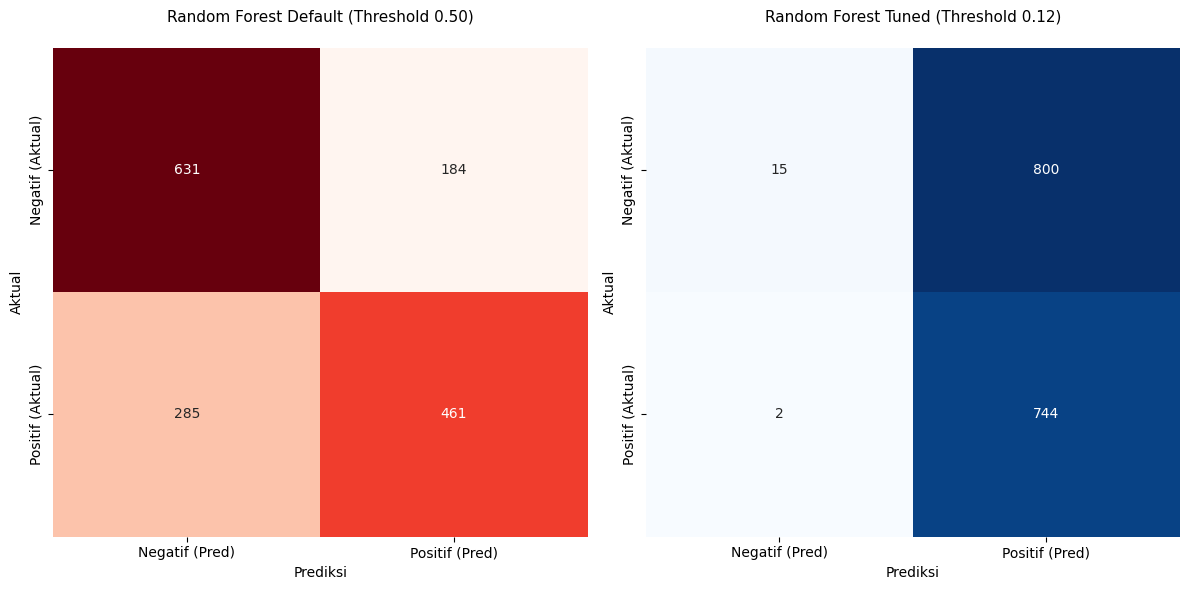

In [64]:
# 1. Hitung matriks kondisi default (0.5)
default_pipeline = Pipeline([('preprocess', preprocess), ('model', rf)])
default_pipeline.fit(X_train, y_train)
y_pred_default = default_pipeline.predict(X_test)
cm_default = confusion_matrix(y_test, y_pred_default)

# 2. Hitung matriks kondisi optimal (0.12)
best_rf_pipeline = best_estimators_from_tuning['Random Forest']
y_proba_tuned = best_rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_proba_tuned >= 0.12).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Plotting berdampingan
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Heatmap Default
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Reds', ax=ax[0], cbar=False,
             xticklabels=['Negatif (Pred)', 'Positif (Pred)'], yticklabels=['Negatif (Aktual)', 'Positif (Aktual)'])
ax[0].set_title('Random Forest Default (Threshold 0.50)\n', fontsize=11)
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Aktual')

# Heatmap Tuned
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False,
            xticklabels=['Negatif (Pred)', 'Positif (Pred)'], yticklabels=['Negatif (Aktual)', 'Positif (Aktual)'])
ax[1].set_title('Random Forest Tuned (Threshold 0.12)\n', fontsize=11)
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

Visualisasi Confusion Matrix menunjukkan secara jelas perbedaan antara model default dan yang sudah dioptimasi:

* Default (Threshold 0.50): Memiliki 285 False Negatives (nasabah yang seharusnya deposit tapi tidak ditargetkan) dan 184 False Positives (nasabah yang tidak deposit tapi ditargetkan).
* Tuned (Threshold 0.12): Hanya memiliki 2 False Negatives, namun False Positives meningkat menjadi 800. Ini berarti model berhasil mengidentifikasi hampir semua nasabah yang akan deposit, tetapi juga menargetkan lebih banyak nasabah yang sebenarnya tidak akan deposit.

### Cost - Benefit Analysis

In [65]:
# Asumsi cost dan benefit
BENEFIT_TP = 250
COST_FP = 10
COST_FN = 250 # Opportunity cost
BENEFIT_TN = 0 # Netral

# Confusion Matrix Default Random Forest
# cm_default = array([[TN, FP],
#                     [FN, TP]])
cm_default = np.array([[631, 184],
                       [285, 461]])

# Confusion Matrix Tuned Random Forest
# cm_tuned = array([[TN, FP],
#                   [FN, TP]])
cm_tuned = np.array([[ 15, 800],
                     [  2, 744]])

# Perhitungan Cost-Benefit
def calculate_net_benefit(cm, benefit_tp, cost_fp, cost_fn, benefit_tn):
    tn, fp, fn, tp = cm.ravel()
    net_benefit = (tp * benefit_tp) - (fp * cost_fp) - (fn * cost_fn) + (tn * benefit_tn)
    return net_benefit, tp, fp, fn, tn

# Hitung untuk kondisi Default
net_benefit_default, tp_default, fp_default, fn_default, tn_default = calculate_net_benefit(
    cm_default, BENEFIT_TP, COST_FP, COST_FN, BENEFIT_TN
)

# Hitung untuk kondisi Tuned
net_benefit_tuned, tp_tuned, fp_tuned, fn_tuned, tn_tuned = calculate_net_benefit(
    cm_tuned, BENEFIT_TP, COST_FP, COST_FN, BENEFIT_TN
)

print("\nAnalisis Cost-Benefit \n" + "="*22)
print("\nKondisi Default (Threshold 0.50):")
print(f" - True Positives (TP): {tp_default} * ${BENEFIT_TP} = ${tp_default * BENEFIT_TP}")
print(f" - False Positives (FP): {fp_default} * -${COST_FP} = ${fp_default * -COST_FP}")
print(f" - False Negatives (FN): {fn_default} * -${COST_FN} = ${fn_default * -COST_FN}")
print(f" - True Negatives (TN): {tn_default} * ${BENEFIT_TN} = ${tn_default * BENEFIT_TN}")
print(f" - Total Manfaat Bersih: ${net_benefit_default}")

print("\nKondisi Optimized (Threshold 0.12):")
print(f" - True Positives (TP): {tp_tuned} * ${BENEFIT_TP} = ${tp_tuned * BENEFIT_TP}")
print(f" - False Positives (FP): {fp_tuned} * -${COST_FP} = ${fp_tuned * -COST_FP}")
print(f" - False Negatives (FN): {fn_tuned} * -${COST_FN} = ${fn_tuned * -COST_FN}")
print(f" - True Negatives (TN): {tn_tuned} * ${BENEFIT_TN} = ${tn_tuned * BENEFIT_TN}")
print(f" - Total Manfaat Bersih: ${net_benefit_tuned}")

print("\nPerbandingan Hasil\n" + "="*20)
print(f"Model Default menghasilkan benefit bersih: ${net_benefit_default}")
print(f"Model Optimized menghasilkan benefit bersih: ${net_benefit_tuned}")

benefit_difference = net_benefit_tuned - net_benefit_default
print(f"Peningkatan benefit bersih dengan model Optimized: ${benefit_difference}")


Analisis Cost-Benefit 

Kondisi Default (Threshold 0.50):
 - True Positives (TP): 461 * $250 = $115250
 - False Positives (FP): 184 * -$10 = $-1840
 - False Negatives (FN): 285 * -$250 = $-71250
 - True Negatives (TN): 631 * $0 = $0
 - Total Manfaat Bersih: $42160

Kondisi Optimized (Threshold 0.12):
 - True Positives (TP): 744 * $250 = $186000
 - False Positives (FP): 800 * -$10 = $-8000
 - False Negatives (FN): 2 * -$250 = $-500
 - True Negatives (TN): 15 * $0 = $0
 - Total Manfaat Bersih: $177500

Perbandingan Hasil
Model Default menghasilkan benefit bersih: $42160
Model Optimized menghasilkan benefit bersih: $177500
Peningkatan benefit bersih dengan model Optimized: $135340


**Analisis _Cost-Benefit_ Model _Random Forest_**

Dengan Asumsi cost dan benefit
*   Cost = 10/Nasabah
*   Benefit = 250/Nasabah

**1. Kondisi Default (Threshold 0.50):**
   *   **Total Benefit Bersih:** 42,160
   *   *True Positives (TP)*: 461 nasabah berhasil diidentifikasi dan melakukan deposit, menghasilkan 115,250.
   *   *False Positives (FP)*: 184 nasabah ditargetkan tetapi tidak deposit, menghasilkan kerugian 1,840.
   *   *False Negatives (FN)*: 285 nasabah tidak ditargetkan padahal akan deposit, kehilangan potensi 71,250.
   *   *True Negatives (TN)*: 631 nasabah tidak ditargetkan dan tidak deposit, menghasilkan 0.

**2. Kondisi Optimized (Threshold 0.12):**
   *   **Total Benefit Bersih:** 177,500
   *   *True Positives (TP)*: 744 nasabah berhasil diidentifikasi dan melakukan deposit, menghasilkan 186,000.
   *   *False Positives (FP)*: 800 nasabah ditargetkan tetapi tidak deposit, menghasilkan kerugian 8,000.
   *   *False Negatives (FN)*: Hanya 2 nasabah yang tidak ditargetkan padahal akan deposit, kehilangan potensi 500.
   *   *True Negatives (TN)*: 15 nasabah tidak ditargetkan dan tidak deposit, menghasilkan 0.

**3. Perbandingan Hasil:**
   *   Model _Optimized_ menghasilkan **peningkatan manfaat bersih sebesar 135,340** dibandingkan model _Default_.

**Kesimpulan:**
Model yang telah dioptimalkan dengan _threshold_ 0.12 secara signifikan meningkatkan manfaat bersih bagi bank dengan memaksimalkan identifikasi nasabah potensial dan meminimalkan kerugian akibat *false negatives*.

### Feature Importances

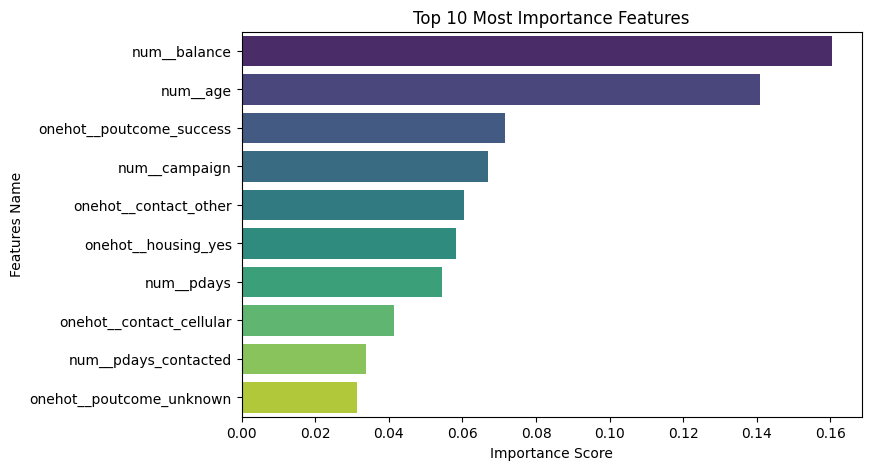

In [66]:
# Ekstrak nama fitur dari preprocessor di dalam pipeline
try:
    feature_names = best_pipeline.named_steps['preprocess'].get_feature_names_out()
except:
    # Jika gagal karena kustomisasi pipeline, gunakan indeks angka sementara
    feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

# Ambil nilai importance dari model Random Forest internal
importances = best_pipeline.named_steps['model'].feature_importances_

# Buat dataframe dan urutkan
df_importance = pd.DataFrame({'Fitur': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)

# Plotting Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Fitur', data=df_importance, palette='viridis')
plt.title('Top 10 Most Importance Features')
plt.xlabel('Importance Score')
plt.ylabel('Features Name')
plt.show()

Insight dari hasil Features Improtance:

Analisis feature importances menunjukkan 10 fitur teratas yang paling berpengaruh pada prediksi model. `num__balance` (saldo) dan `num__age` (usia) menjadi fitur paling penting dan mungkin sangat bergantung, diikuti oleh `onehot__poutcome_success` (hasil kampanye sebelumnya  yang 'sukses'), efesiensi kampanye `num__campaign`, dan `onehot_contact` sebagai metode kontak, dan diikuti fitur-fitur lainnya. Informasi bersifat sangat berharga untuk memahami faktor-faktor kunci untuk tim pemasaran dalam menargetkan nasabah yang paling berpotensi untuk melakukan deposit.

## Kesimpulan dan Rekomendasi

Berikut adalah kesimpulan menyeluruh dari analisis ini, serta rekomendasi yang dapat ditindaklanjuti untuk strategi pemasaran bank:

Kesimpulan

1.  **Fokus pada Minimasi *False Negatives* Berhasil**: Tujuan utama proyek ini, yaitu memaksimalkan F2-Score dan Recall serta meminimalkan *False Negatives* (FN), berhasil dicapai melalui optimasi model dan *threshold*.
2.  **Model *Random Forest* Terpilih**: Setelah proses *hyperparameter tuning* dan optimasi *threshold*, model **Random Forest** dengan *threshold* **0.12** terbukti menjadi model terbaik.
3.  **Peningkatan Performa Model Signifikan**:
    *   **F2-Score**: Meningkat drastis dari **0.6352** menjadi **0.8216**.
    *   **Recall**: Melonjak dari **0.6180** menjadi **0.9973** (hampir sempurna dalam mengidentifikasi nasabah yang akan deposit).
    *   ***False Negatives***: Berhasil ditekan secara ekstrem, dari **285** menjadi hanya **2**.
    *   Meskipun *Precision* menurun (dari 0.7147 menjadi 0.4819), hal ini diterima karena prioritas proyek adalah minimisasi FN, yang mencerminkan *opportunity cost* yang lebih tinggi bagi bank.
4.  **Manfaat Bisnis yang Konkret**: Model yang dioptimasi menghasilkan **Benefit bersih sebesar 177,500**, menunjukkan **peningkatan manfaat bersih sebesar 135,340** dibandingkan model default (42,160). Ini memvalidasi keberhasilan strategi untuk meminimalkan kerugian akibat kehilangan potensi nasabah.
5.  **Faktor-faktor Kunci yang Mempengaruhi Deposit**: Fitur-fitur seperti `num__balance` (saldo), `num__age` (usia), `onehot__poutcome_success` (hasil kampanye sebelumnya yang sukses), `num__campaign` (jumlah kontak), `onehot__contact_cellular` (metode kontak seluler), dan bulan-bulan tertentu (`onehot__month_mar`, `onehot__month_dec`, `onehot__month_oct`) adalah prediktor paling signifikan.

Rekomendasi

Berdasarkan kesimpulan di atas, berikut adalah rekomendasi strategis bagi bank untuk meningkatkan efektivitas kampanye pemasaran deposit:

1.  **Prioritaskan Segmen Nasabah Potensial Tinggi**:
    *   **Riwayat *Success***: Targetkan nasabah yang memiliki riwayat `poutcome_success` karena probabilitas mereka untuk deposit kembali sangat tinggi.
    *   **Pekerjaan**: Fokuskan upaya pada segmen **Student, Retired, dan Unemployed** yang memiliki tingkat konversi deposit paling tinggi.
    *   **Kelompok Usia**: Prioritaskan **Older Adults (61-75 tahun), Seniors (76-95 tahun), dan Young Adults (18-25 tahun)**.
    *   **Saldo Tinggi**: Berikan perhatian khusus pada nasabah dengan `balance` yang lebih tinggi.

2.  **Optimasi Saluran dan Waktu Kontak**:
    *   **Saluran *Cellular***: Gunakan metode kontak `cellular` sebagai saluran utama karena terbukti paling efektif.
    *   **Waktu Kampanye**: Maksimalkan kampanye pada bulan-bulan dengan tingkat konversi tinggi seperti **Maret, Desember, dan Oktober**. Kurangi intensitas atau ubah strategi di bulan-bulan dengan konversi rendah (misalnya, Mei, Juli).
    *   **Frekuensi Kontak**: Hindari kontak yang berlebihan (`num__campaign` yang tinggi), karena dapat menjadi kontraproduktif. Model menunjukkan bahwa efektivitas menurun dengan jumlah kontak yang terlalu banyak.

3.  **Strategi untuk Nasabah *Never Contacted* / *Unknown***:
    *   Untuk nasabah yang `pdays_bin` adalah `never_contacted` atau `poutcome` adalah `unknown`, diperlukan strategi *awareness* awal atau penawaran yang lebih menarik untuk membangun kepercayaan sebelum mendorong deposit.
    *   Pertimbangkan untuk mengumpulkan data lebih lanjut mengenai nasabah di segmen ini untuk personalisasi yang lebih baik.

4.  **Implementasi Model**: Integrasikan model Random Forest yang telah dioptimasi ke dalam sistem operasional pemasaran bank. Pastikan untuk secara berkala memonitor performa model di lingkungan produksi dan melakukan *retraining* sesuai kebutuhan untuk menjaga akurasi.